# WTI Swap Data: Preprocessing and EDA

Complete pipeline: Load ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Clean ÃƒÂ¢Ã¢â‚¬Â Ã¢â‚¬â„¢ Analyze

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Raw Data

In [2]:
# Load WTI swap data
df = pd.read_parquet('../data/analysis/wti_swap_only.parquet')

print(f"Original dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Date range: {df['ASSESSDATE'].min()} to {df['ASSESSDATE'].max()}")
print(f"Unique symbols: {df['SYMBOL'].nunique()}")

Original dataset shape: (3714476, 37)
Memory usage: 1946.99 MB
Date range: 2012-06-21 00:00:00 to 2026-04-28 00:00:00
Unique symbols: 301


## 2. Data Preprocessing

### 2.1 Identify Issues

In [3]:
# Check missing values
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

print("Missing values by column:")
print(missing[missing['Missing_Count'] > 0])

Missing values by column:
                               Missing_Count  Missing_Percentage
DAY_OF_PUBLICATION                   3714476              100.00
DELIVERY_LOAD                        3714476              100.00
PADD_REGION                          3714476              100.00
COMMODITY_FORM                       3714476              100.00
BENCHMARK                            3714476              100.00
CONTRACT_YEAR                        2056214               55.36
CONTRACT_MONTH_NAME                  2056214               55.36
DERIVATIVE_POSITION                  1665232               44.83
DERIVATIVE_MATURITY_FREQUENCY        1665232               44.83
CURRENCY                                6970                0.19
UOM                                     6970                0.19


### 2.2 Remove Blank Columns

In [4]:
# Remove columns that are 100% missing
df_clean = df.copy()

missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100)
cols_to_drop = missing_pct[missing_pct == 100].index.tolist()

print(f"Columns with 100% missing values ({len(cols_to_drop)}):")
for col in cols_to_drop:
    print(f"  - {col}")

df_clean = df_clean.drop(columns=cols_to_drop)
print(f"\nShape after removing blank columns: {df_clean.shape}")

Columns with 100% missing values (5):
  - COMMODITY_FORM
  - BENCHMARK
  - PADD_REGION
  - DELIVERY_LOAD
  - DAY_OF_PUBLICATION

Shape after removing blank columns: (3714476, 32)


### 2.3 Remove Invalid Data

In [5]:
# Remove rows with missing VALUE
print(f"Rows with missing VALUE: {df_clean['VALUE'].isnull().sum()}")
df_clean = df_clean[df_clean['VALUE'].notna()]
print(f"After removing missing VALUE: {df_clean.shape}")

Rows with missing VALUE: 0
After removing missing VALUE: (3714476, 32)


In [6]:
# Remove invalid prices (<=0 for Close/Open/High/Low)
price_bates = ['Close', 'Open', 'High', 'Low']
price_mask = df_clean['BATE_NAME'].isin(price_bates)

invalid_prices = df_clean[price_mask & (df_clean['VALUE'] <= 0)]
print(f"Invalid prices (<=0): {len(invalid_prices)}")
if len(invalid_prices) > 0:
    print("\nSample invalid prices:")
    print(invalid_prices[['ASSESSDATE', 'SYMBOL', 'BATE_NAME', 'VALUE']].head())

df_clean = df_clean[~(price_mask & (df_clean['VALUE'] <= 0))]
print(f"\nAfter removing invalid prices: {df_clean.shape}")

Invalid prices (<=0): 0

After removing invalid prices: (3714476, 32)


In [7]:
# Remove outliers (prices > $200/bbl)
outlier_mask = price_mask & (df_clean['VALUE'] > 200)
outliers = df_clean[outlier_mask]
print(f"Outlier prices (>$200/bbl): {len(outliers)}")
if len(outliers) > 0:
    print("\nSample outliers:")
    print(outliers[['ASSESSDATE', 'SYMBOL', 'BATE_NAME', 'VALUE']].head())

df_clean = df_clean[~outlier_mask]
print(f"\nAfter removing outliers: {df_clean.shape}")

Outlier prices (>$200/bbl): 0

After removing outliers: (3714476, 32)


In [8]:
# Remove rows with missing critical identifiers
print(f"Missing ASSESSDATE: {df_clean['ASSESSDATE'].isnull().sum()}")
print(f"Missing SYMBOL: {df_clean['SYMBOL'].isnull().sum()}")

df_clean = df_clean[df_clean['ASSESSDATE'].notna() & df_clean['SYMBOL'].notna()]
print(f"\nAfter removing missing identifiers: {df_clean.shape}")

Missing ASSESSDATE: 0
Missing SYMBOL: 0

After removing missing identifiers: (3714476, 32)


In [9]:
# Remove duplicates
duplicates = df_clean.duplicated(subset=['ASSESSDATE', 'SYMBOL', 'BATE'], keep='first')
print(f"Duplicate rows: {duplicates.sum()}")

df_clean = df_clean[~duplicates]
print(f"After removing duplicates: {df_clean.shape}")

Duplicate rows: 0
After removing duplicates: (3714476, 32)


### 2.4 Preprocessing Summary

In [10]:
print("="*60)
print("PREPROCESSING SUMMARY")
print("="*60)
print(f"Original dataset: {df.shape}")
print(f"Cleaned dataset: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean):,} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")
print(f"Columns removed: {len(df.columns) - len(df_clean.columns)}")
print(f"\nMemory usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Remaining missing values
missing_after = pd.DataFrame({
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percentage': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

print("\nRemaining missing values:")
print(missing_after[missing_after['Missing_Count'] > 0])

PREPROCESSING SUMMARY
Original dataset: (3714476, 37)
Cleaned dataset: (3714476, 32)
Rows removed: 0 (0.00%)
Columns removed: 5

Memory usage: 1803.08 MB

Remaining missing values:
                               Missing_Count  Missing_Percentage
CONTRACT_YEAR                        2056214               55.36
CONTRACT_MONTH_NAME                  2056214               55.36
DERIVATIVE_POSITION                  1665232               44.83
DERIVATIVE_MATURITY_FREQUENCY        1665232               44.83
UOM                                     6970                0.19
CURRENCY                                6970                0.19


In [11]:
# Save cleaned data
df_clean.to_parquet('../data/analysis/wti_swap_cleaned.parquet', index=False)
print("Cleaned data saved to: ../data/analysis/wti_swap_cleaned.parquet")

Cleaned data saved to: ../data/analysis/wti_swap_cleaned.parquet


## 3. Exploratory Data Analysis

### 3.1 Data Structure

BATE types:
BATE_NAME
Open Interest    621204
Volume           621204
Close            618017
High             618017
Low              618017
Open             618017
Name: count, dtype: int64[pyarrow]


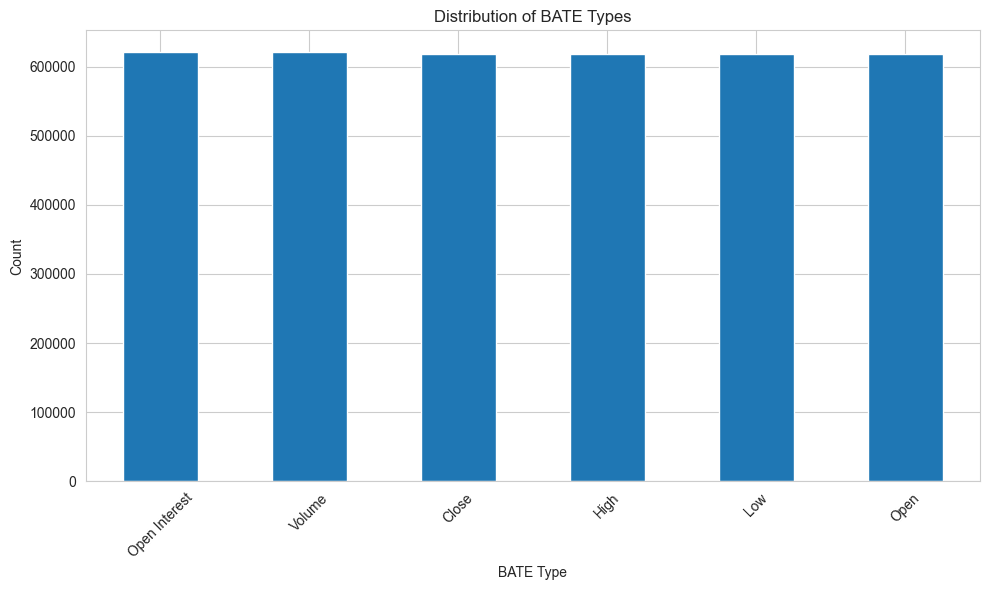

In [12]:
# BATE types distribution
print("BATE types:")
print(df_clean['BATE_NAME'].value_counts())

# Visualize
plt.figure(figsize=(10, 6))
df_clean['BATE_NAME'].value_counts().plot(kind='bar')
plt.title('Distribution of BATE Types')
plt.xlabel('BATE Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Sample of cleaned data
df_clean.head(20)

,PRICE_FAMILY,ASSESSDATE,SYMBOL,BATE,BATE_NAME,VALUE,UOM,CURRENCY,ISCORRECTED,MDC,DESCRIPTION,SYMBOL_FAMILY,COMMODITY,COMMODITY_GRADE,EXCHANGE,CONTRACT_TYPE,SETTLEMENT_TYPE,DERIVATIVE_POSITION,DERIVATIVE_MATURITY_FREQUENCY,CONTRACT_MONTH_NAME,CONTRACT_YEAR,SYMBOL_MDC_DESCRIPTION,MDC_CATEGORY,DELIVERY_REGION,DELIVERY_METHOD,DECIMAL_PLACES,API_GRAVITY,SULFUR,DENSITY,ASSESSMENT_FREQUENCY,QUOTATION_STYLE,ACTIVE
0,wti_swap,2012-06-21,XNCW000,e,Open Interest,202804.0,<NA>,<NA>,N,IX,NYMEX WTI Calendar Swap Cont Tot Elect,WTI_SWAP,Crude oil,NYMEX - Light Sweet Crude - Chapter 200,NYMEX,Swap,Physical,NaN,<NA>,<NA>,NaN,IX-Futures/Nearbys: NYMEX Swap Contracts,Futures/Swaps,United States,Pipeline,2,37.0,0.42,837.8,Daily (weekday),Flat,Active - Public
1,wti_swap,2012-06-21,XNCW000,w,Volume,2648.0,<NA>,<NA>,N,IX,NYMEX WTI Calendar Swap Cont Tot Elect,WTI_SWAP,Crude oil,NYMEX - Light Sweet Crude - Chapter 200,NYMEX,Swap,Physical,NaN,<NA>,<NA>,NaN,IX-Futures/Nearbys: NYMEX Swap Contracts,Futures/Swaps,United States,Pipeline,2,37.0,0.42,837.8,Daily (weekday),Flat,Active - Public
2,wti_swap,2012-06-22,XNCW000,e,Open Interest,202854.0,<NA>,<NA>,N,IX,NYMEX WTI Calendar Swap Cont Tot Elect,WTI_SWAP,Crude oil,NYMEX - Light Sweet Crude - Chapter 200,NYMEX,Swap,Physical,NaN,<NA>,<NA>,NaN,IX-Futures/Nearbys: NYMEX Swap Contracts,Futures/Swaps,United States,Pipeline,2,37.0,0.42,837.8,Daily (weekday),Flat,Active - Public
3,wti_swap,2012-06-22,XNCW000,w,Volume,947.0,<NA>,<NA>,N,IX,NYMEX WTI Calendar Swap Cont Tot Elect,WTI_SWAP,Crude oil,NYMEX - Light Sweet Crude - Chapter 200,NYMEX,Swap,Physical,NaN,<NA>,<NA>,NaN,IX-Futures/Nearbys: NYMEX Swap Contracts,Futures/Swaps,United States,Pipeline,2,37.0,0.42,837.8,Daily (weekday),Flat,Active - Public
4,wti_swap,2012-06-25,XNCW000,e,Open Interest,203004.0,<NA>,<NA>,N,IX,NYMEX WTI Calendar Swap Cont Tot Elect,WTI_SWAP,Crude oil,NYMEX - Light Sweet Crude - Chapter 200,NYMEX,Swap,Physical,NaN,<NA>,<NA>,NaN,IX-Futures/Nearbys: NYMEX Swap Contracts,Futures/Swaps,United States,Pipeline,2,37.0,0.42,837.8,Daily (weekday),Flat,Active - Public
5,wti_swap,2012-06-25,XNCW000,w,Volume,1972.0,<NA>,<NA>,N,IX,NYMEX WTI Calendar Swap Cont Tot Elect,WTI_SWAP,Crude oil,NYMEX - Light Sweet Crude - Chapter 200,NYMEX,Swap,Physical,NaN,<NA>,<NA>,NaN,IX-Futures/Nearbys: NYMEX Swap Contracts,Futures/Swaps,United States,Pipeline,2,37.0,0.42,837.8,Daily (weekday),Flat,Active - Public
6,wti_swap,2012-06-26,XNCW000,e,Open Interest,202324.0,<NA>,<NA>,N,IX,NYMEX WTI Calendar Swap Cont Tot Elect,WTI_SWAP,Crude oil,NYMEX - Light Sweet Crude - Chapter 200,NYMEX,Swap,Physical,NaN,<NA>,<NA>,NaN,IX-Futures/Nearbys: NYMEX Swap Contracts,Futures/Swaps,United States,Pipeline,2,37.0,0.42,837.8,Daily (weekday),Flat,Active - Public
7,wti_swap,2012-06-26,XNCW000,w,Volume,2462.0,<NA>,<NA>,N,IX,NYMEX WTI Calendar Swap Cont Tot Elect,WTI_SWAP,Crude oil,NYMEX - Light Sweet Crude - Chapter 200,NYMEX,Swap,Physical,NaN,<NA>,<NA>,NaN,IX-Futures/Nearbys: NYMEX Swap Contracts,Futures/Swaps,United States,Pipeline,2,37.0,0.42,837.8,Daily (weekday),Flat,Active - Public
8,wti_swap,2012-06-27,XNCW000,e,Open Interest,202012.0,<NA>,<NA>,N,IX,NYMEX WTI Calendar Swap Cont Tot Elect,WTI_SWAP,Crude oil,NYMEX - Light Sweet Crude - Chapter 200,NYMEX,Swap,Physical,NaN,<NA>,<NA>,NaN,IX-Futures/Nearbys: NYMEX Swap Contracts,Futures/Swaps,United States,Pipeline,2,37.0,0.42,837.8,Daily (weekday),Flat,Active - Public
9,wti_swap,2012-06-27,XNCW000,w,Volume,2511.0,<NA>,<NA>,N,IX,NYMEX WTI Calendar Swap Cont Tot Elect,WTI_SWAP,Crude oil,NYMEX - Light Sweet Crude - Chapter 200,NYMEX,Swap,Physical,NaN,<NA>,<NA>,NaN,IX-Futures/Nearbys: NYMEX Swap Contracts,Futures/Swaps,United States,Pipeline,2,37.0,0.42,837.8,Daily (weekday),Flat,Active - Public


In [14]:
# Data types
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 3714476 entries, 0 to 3714475
Data columns (total 32 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   PRICE_FAMILY                   string        
 1   ASSESSDATE                     datetime64[ns]
 2   SYMBOL                         string        
 3   BATE                           string        
 4   BATE_NAME                      string        
 5   VALUE                          float64       
 6   UOM                            string        
 7   CURRENCY                       string        
 8   ISCORRECTED                    string        
 9   MDC                            string        
 10  DESCRIPTION                    string        
 11  SYMBOL_FAMILY                  string        
 12  COMMODITY                      string        
 13  COMMODITY_GRADE                string        
 14  EXCHANGE                       string        
 15  CONTRACT_TYPE             

### 3.2 Symbol Analysis

In [15]:
# Top symbols
print("Top 20 symbols by record count:")
print(df_clean['SYMBOL'].value_counts().head(20))

Top 20 symbols by record count:
SYMBOL
XNCW018    20908
XNCW019    20908
XNCW020    20908
XNCW021    20908
XNCW022    20908
XNCW023    20908
XNCW024    20908
XNCW025    20908
XNCW061    20908
XNCW062    20908
XNCW063    20908
XNCW064    20908
XNCW065    20908
XNCW066    20908
XNCW067    20908
XNCW068    20908
XNCW069    20908
XNCW004    20906
XNCW005    20906
XNCW006    20906
Name: count, dtype: int64[pyarrow]


In [16]:
# Contract months and years (for calendar swaps)
print("Contract months:")
print(df_clean['CONTRACT_MONTH_NAME'].value_counts())

print("\nContract years:")
print(df_clean['CONTRACT_YEAR'].value_counts().sort_index())

Contract months:
CONTRACT_MONTH_NAME
Dec    143134
Nov    142234
Oct    141381
Sep    140456
Aug    139594
Jul    138672
Jun    137780
May    136910
Apr    136017
Mar    135032
Feb    133986
Jan    133066
Name: count, dtype: int64[pyarrow]

Contract years:
CONTRACT_YEAR
2019.0    128081
2020.0    146264
2021.0    135294
2022.0    153425
2023.0    154722
2024.0    112728
2025.0    130800
2026.0    144206
2027.0    132550
2028.0    114408
2029.0     96192
2030.0     78048
2031.0     59976
2032.0     41976
2033.0     23832
2034.0      5760
Name: count, dtype: int64


### 3.3 Price Analysis

In [17]:
# Filter to Close prices for analysis
close_df = df_clean[df_clean['BATE_NAME'] == 'Close'].copy()

print(f"Close price records: {len(close_df):,}")
print(f"\nClose price statistics:")
print(close_df['VALUE'].describe())

Close price records: 618,017

Close price statistics:
count    618017.000000
mean         62.137750
std          12.170031
min          14.060000
25%          53.290000
50%          60.890000
75%          67.320000
max         120.300000
Name: VALUE, dtype: float64


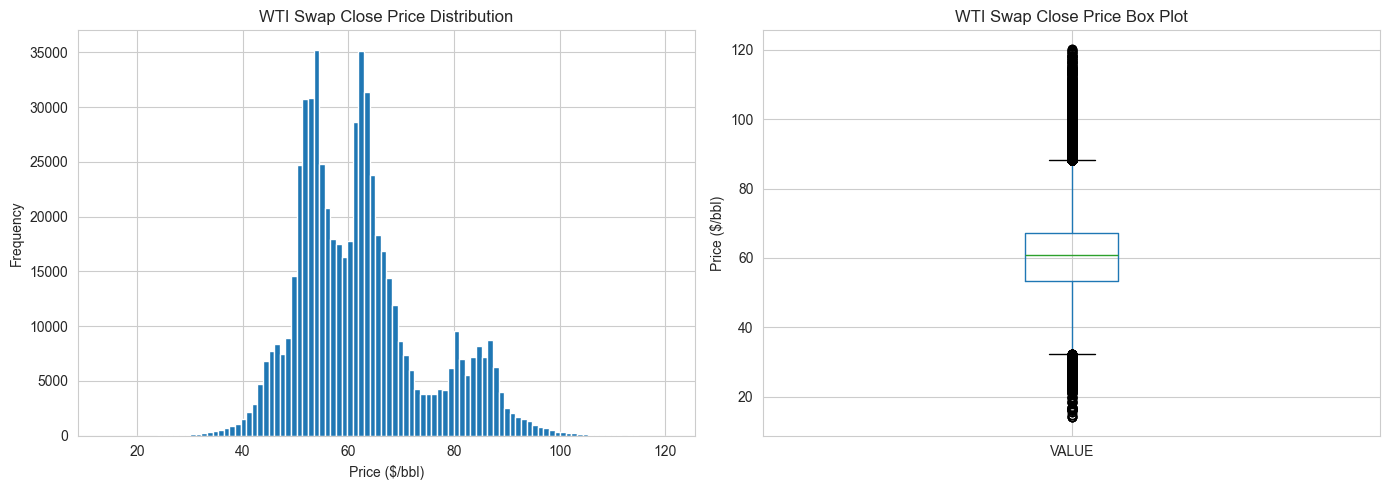

In [18]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

close_df['VALUE'].hist(bins=100, ax=axes[0])
axes[0].set_title('WTI Swap Close Price Distribution')
axes[0].set_xlabel('Price ($/bbl)')
axes[0].set_ylabel('Frequency')

close_df.boxplot(column='VALUE', ax=axes[1])
axes[1].set_title('WTI Swap Close Price Box Plot')
axes[1].set_ylabel('Price ($/bbl)')

plt.tight_layout()
plt.show()

### 3.4 Time Series Analysis

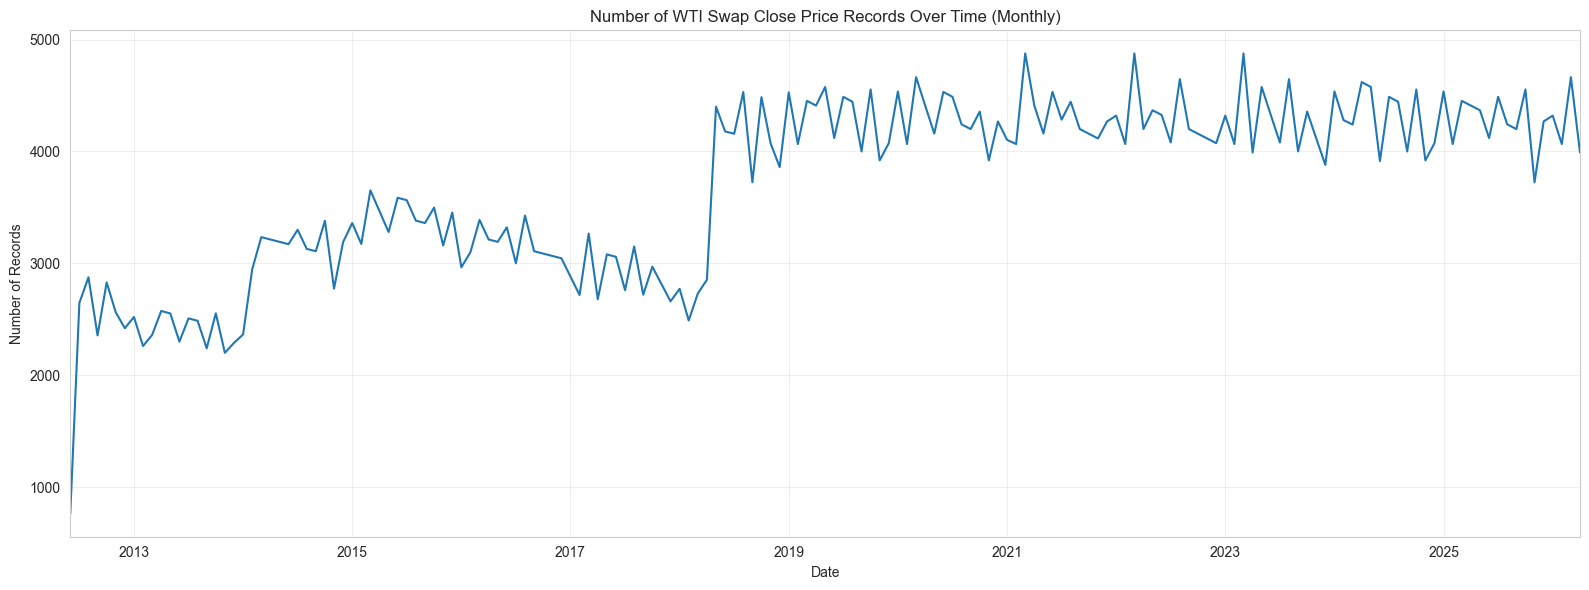

In [19]:
# Records over time
time_series = close_df.groupby(close_df['ASSESSDATE'].dt.to_period('M')).size()

plt.figure(figsize=(16, 6))
time_series.plot()
plt.title('Number of WTI Swap Close Price Records Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Prompt month (XNCW000) close price records: 0
No close price data for prompt month (XNCW000)
Using XNCW001 (1-month forward) instead...


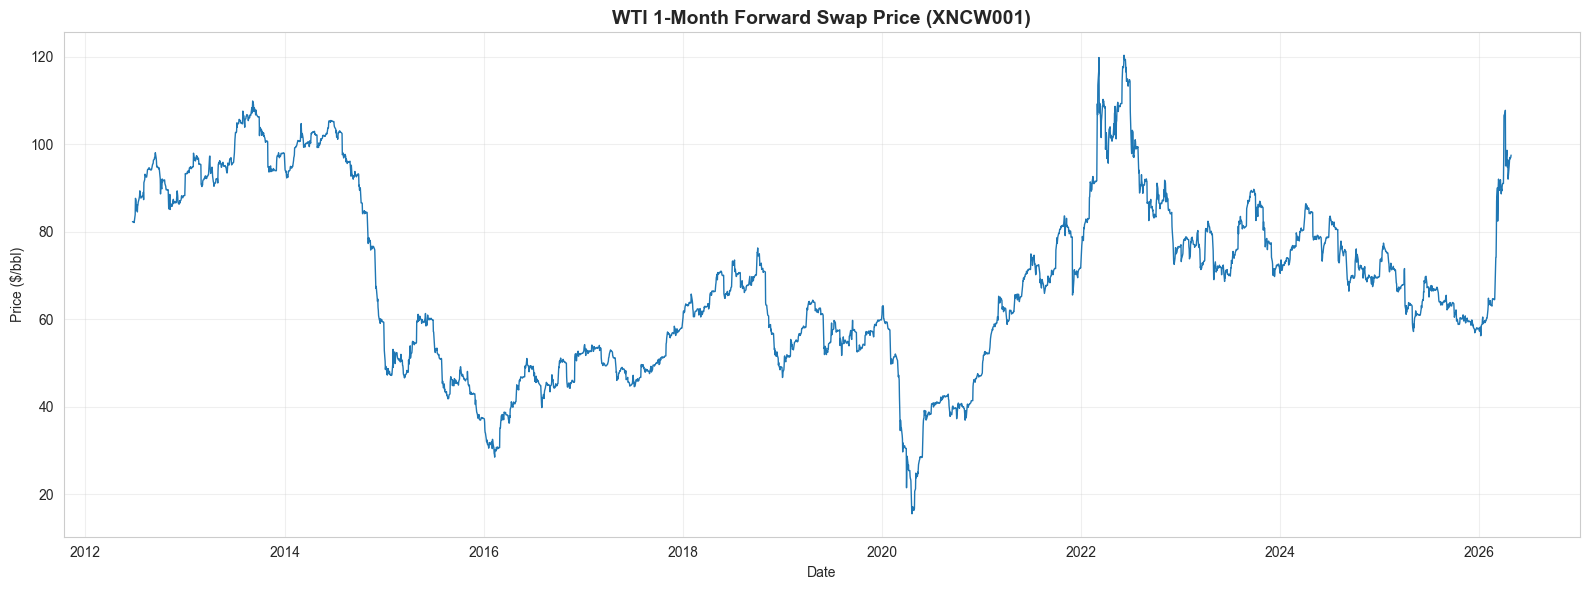

In [20]:
# Extract forward position from symbol
def extract_position(symbol):
    if not isinstance(symbol, str) or not symbol.startswith('XNCW'):
        return None
    suffix = symbol[4:]
    if suffix.isdigit():
        return int(suffix)
    return None

close_df['FORWARD_POSITION'] = close_df['SYMBOL'].apply(extract_position)

# Check if we have prompt month data
prompt = close_df[close_df['SYMBOL'] == 'XNCW000'].copy()
print(f"Prompt month (XNCW000) close price records: {len(prompt)}")

if len(prompt) > 0:
    prompt = prompt.sort_values('ASSESSDATE')
    plt.figure(figsize=(16, 6))
    plt.plot(prompt['ASSESSDATE'], prompt['VALUE'], linewidth=1)
    plt.title('WTI Prompt Month Swap Price (XNCW000)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Price ($/bbl)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No close price data for prompt month (XNCW000)")
    print("Using XNCW001 (1-month forward) instead...")
    
    m1 = close_df[close_df['SYMBOL'] == 'XNCW001'].copy()
    if len(m1) > 0:
        m1 = m1.sort_values('ASSESSDATE')
        plt.figure(figsize=(16, 6))
        plt.plot(m1['ASSESSDATE'], m1['VALUE'], linewidth=1)
        plt.title('WTI 1-Month Forward Swap Price (XNCW001)', fontsize=14, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Price ($/bbl)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

### 3.5 Forward Curve Analysis

In [21]:
# Filter to numeric forward positions
forward_df = close_df[close_df['FORWARD_POSITION'].notna()].copy()

print(f"Records with numeric forward positions: {len(forward_df):,}")
print(f"Forward position range: {forward_df['FORWARD_POSITION'].min():.0f} to {forward_df['FORWARD_POSITION'].max():.0f} months")

Records with numeric forward positions: 341,591
Forward position range: 1 to 108 months


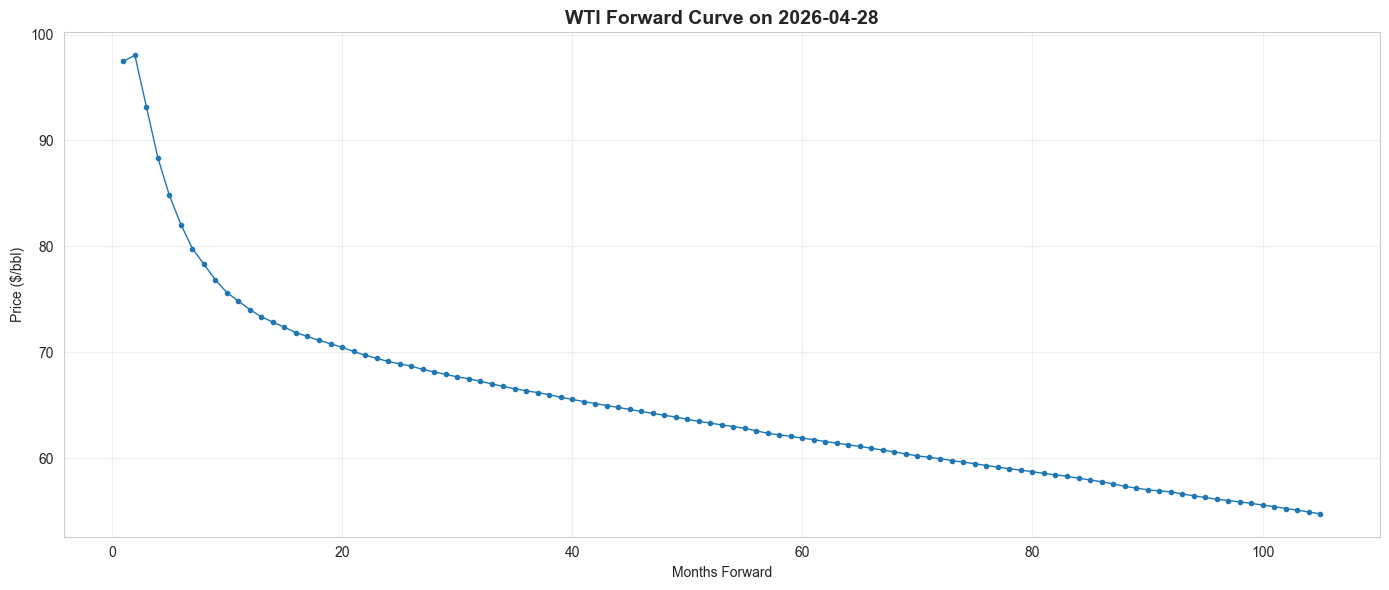


Curve shape: Backwardation
Front month: $97.48
12-month: $74.02


In [22]:
# Sample forward curve for latest date
sample_date = forward_df['ASSESSDATE'].max()
curve = forward_df[forward_df['ASSESSDATE'] == sample_date].copy()
curve = curve.sort_values('FORWARD_POSITION')

if len(curve) > 0:
    plt.figure(figsize=(14, 6))
    plt.plot(curve['FORWARD_POSITION'], curve['VALUE'], marker='o', markersize=3, linewidth=1)
    plt.title(f'WTI Forward Curve on {sample_date.date()}', fontsize=14, fontweight='bold')
    plt.xlabel('Months Forward')
    plt.ylabel('Price ($/bbl)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    if len(curve) > 1:
        curve_shape = 'Contango' if curve['VALUE'].iloc[-1] > curve['VALUE'].iloc[0] else 'Backwardation'
        print(f"\nCurve shape: {curve_shape}")
        print(f"Front month: ${curve['VALUE'].iloc[0]:.2f}")
        if len(curve) > 12:
            m12 = curve[curve['FORWARD_POSITION'] == 12]
            if len(m12) > 0:
                print(f"12-month: ${m12['VALUE'].values[0]:.2f}")

### 3.6 Volume and Open Interest

In [23]:
# Volume and Open Interest analysis
volume_df = df_clean[df_clean['BATE_NAME'] == 'Volume'].copy()
oi_df = df_clean[df_clean['BATE_NAME'] == 'Open Interest'].copy()

print(f"Volume records: {len(volume_df):,}")
print(f"Open Interest records: {len(oi_df):,}")

if len(volume_df) > 0:
    print(f"\nVolume statistics:")
    print(volume_df['VALUE'].describe())

if len(oi_df) > 0:
    print(f"\nOpen Interest statistics:")
    print(oi_df['VALUE'].describe())

Volume records: 621,204
Open Interest records: 621,204

Volume statistics:
count    621204.000000
mean         35.855880
std         287.289277
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       73654.000000
Name: VALUE, dtype: float64

Open Interest statistics:
count    621204.000000
mean       2206.564042
std       11702.231954
min           0.000000
25%           0.000000
50%          62.000000
75%         960.000000
max      235004.000000
Name: VALUE, dtype: float64


### 3.7 Data Quality Summary

In [24]:
# Corrected records
print("Corrected records:")
print(df_clean['ISCORRECTED'].value_counts())

# Check for any remaining anomalies
print(f"\nPrice range (Close/Open/High/Low):")
price_data = df_clean[df_clean['BATE_NAME'].isin(['Close', 'Open', 'High', 'Low'])]
print(f"Min: ${price_data['VALUE'].min():.2f}")
print(f"Max: ${price_data['VALUE'].max():.2f}")
print(f"Mean: ${price_data['VALUE'].mean():.2f}")
print(f"Median: ${price_data['VALUE'].median():.2f}")

Corrected records:
ISCORRECTED
N    3714466
Y         10
Name: count, dtype: int64[pyarrow]

Price range (Close/Open/High/Low):
Min: $14.06
Max: $120.30
Mean: $62.14
Median: $60.89


<!-- HIDDEN: Feature Engineering (runs in background) -->



In [25]:
# Focus on XNCW001 (1-month forward) Close prices
m1_close = df_clean[(df_clean['SYMBOL'] == 'XNCW001') & 
                     (df_clean['BATE_NAME'] == 'Close')].copy()
m1_close = m1_close.sort_values('ASSESSDATE').reset_index(drop=True)

print(f"M1 Close price records: {len(m1_close)}")
print(f"Date range: {m1_close['ASSESSDATE'].min()} to {m1_close['ASSESSDATE'].max()}")
print(f"\nSample:")
print(m1_close[['ASSESSDATE', 'VALUE']].head())

M1 Close price records: 3485
Date range: 2012-06-22 00:00:00 to 2026-04-28 00:00:00

Sample:
  ASSESSDATE  VALUE
0 2012-06-22  82.28
1 2012-06-25  82.15
2 2012-06-26  82.18
3 2012-06-27  82.30
4 2012-06-28  82.06


In [26]:
# Create target variable: Next day return
m1_close['Price'] = m1_close['VALUE']
m1_close['Return'] = m1_close['Price'].pct_change()
m1_close['Next_Day_Return'] = m1_close['Return'].shift(-1)  # Target variable

print("Target variable created:")
print(m1_close[['ASSESSDATE', 'Price', 'Return', 'Next_Day_Return']].head(10))

print(f"\nNext Day Return statistics:")
print(m1_close['Next_Day_Return'].describe())

Target variable created:
  ASSESSDATE  Price    Return  Next_Day_Return
0 2012-06-22  82.28       NaN        -0.001580
1 2012-06-25  82.15 -0.001580         0.000365
2 2012-06-26  82.18  0.000365         0.001460
3 2012-06-27  82.30  0.001460        -0.002916
4 2012-06-28  82.06 -0.002916         0.004265
5 2012-06-29  82.41  0.004265         0.017838
6 2012-07-02  83.88  0.017838         0.044349
7 2012-07-03  87.60  0.044349        -0.004680
8 2012-07-05  87.19 -0.004680        -0.027067
9 2012-07-06  84.83 -0.027067         0.014617

Next Day Return statistics:
count    3484.000000
mean        0.000266
std         0.020644
min        -0.297743
25%        -0.004764
50%         0.000334
75%         0.005491
max         0.245706
Name: Next_Day_Return, dtype: float64


### 5.2 Create Features

In [27]:
# Price-based features
m1_close['Price_Lag1'] = m1_close['Price'].shift(1)
m1_close['Price_Lag2'] = m1_close['Price'].shift(2)
m1_close['Price_Lag3'] = m1_close['Price'].shift(3)
m1_close['Price_Lag5'] = m1_close['Price'].shift(5)

# Return-based features
m1_close['Return_Lag1'] = m1_close['Return'].shift(1)
m1_close['Return_Lag2'] = m1_close['Return'].shift(2)
m1_close['Return_Lag3'] = m1_close['Return'].shift(3)
m1_close['Return_Lag5'] = m1_close['Return'].shift(5)

# Moving averages
m1_close['MA_5'] = m1_close['Price'].rolling(5).mean()
m1_close['MA_10'] = m1_close['Price'].rolling(10).mean()
m1_close['MA_20'] = m1_close['Price'].rolling(20).mean()
m1_close['MA_50'] = m1_close['Price'].rolling(50).mean()

# Price relative to moving averages
m1_close['Price_to_MA5'] = m1_close['Price'] / m1_close['MA_5'] - 1
m1_close['Price_to_MA20'] = m1_close['Price'] / m1_close['MA_20'] - 1

# Volatility features
m1_close['Volatility_5'] = m1_close['Return'].rolling(5).std()
m1_close['Volatility_10'] = m1_close['Return'].rolling(10).std()
m1_close['Volatility_20'] = m1_close['Return'].rolling(20).std()

# Momentum features
m1_close['Momentum_5'] = m1_close['Price'] / m1_close['Price'].shift(5) - 1
m1_close['Momentum_10'] = m1_close['Price'] / m1_close['Price'].shift(10) - 1
m1_close['Momentum_20'] = m1_close['Price'] / m1_close['Price'].shift(20) - 1

# RSI (Relative Strength Index)
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

m1_close['RSI_14'] = calculate_rsi(m1_close['Price'], 14)

# Temporal features
m1_close['Day_of_Week'] = m1_close['ASSESSDATE'].dt.dayofweek
m1_close['Month'] = m1_close['ASSESSDATE'].dt.month
m1_close['Quarter'] = m1_close['ASSESSDATE'].dt.quarter

print(f"Features created. Total columns: {len(m1_close.columns)}")
print(f"\nFeature columns:")
feature_cols = [col for col in m1_close.columns if col not in ['ASSESSDATE', 'VALUE', 'Price', 'Return', 'Next_Day_Return'] 
                and not col.startswith('PRICE_') and not col.startswith('SYMBOL') and not col.startswith('BATE')]
for col in feature_cols:
    print(f"  - {col}")

Features created. Total columns: 59

Feature columns:
  - UOM
  - CURRENCY
  - ISCORRECTED
  - MDC
  - DESCRIPTION
  - COMMODITY
  - COMMODITY_GRADE
  - EXCHANGE
  - CONTRACT_TYPE
  - SETTLEMENT_TYPE
  - DERIVATIVE_POSITION
  - DERIVATIVE_MATURITY_FREQUENCY
  - CONTRACT_MONTH_NAME
  - CONTRACT_YEAR
  - MDC_CATEGORY
  - DELIVERY_REGION
  - DELIVERY_METHOD
  - DECIMAL_PLACES
  - API_GRAVITY
  - SULFUR
  - DENSITY
  - ASSESSMENT_FREQUENCY
  - QUOTATION_STYLE
  - ACTIVE
  - Price_Lag1
  - Price_Lag2
  - Price_Lag3
  - Price_Lag5
  - Return_Lag1
  - Return_Lag2
  - Return_Lag3
  - Return_Lag5
  - MA_5
  - MA_10
  - MA_20
  - MA_50
  - Price_to_MA5
  - Price_to_MA20
  - Volatility_5
  - Volatility_10
  - Volatility_20
  - Momentum_5
  - Momentum_10
  - Momentum_20
  - RSI_14
  - Day_of_Week
  - Month
  - Quarter


### 5.3 Add Volume and Open Interest Features

In [28]:
# Get Volume and Open Interest for XNCW001
m1_volume = df_clean[(df_clean['SYMBOL'] == 'XNCW001') & 
                      (df_clean['BATE_NAME'] == 'Volume')][['ASSESSDATE', 'VALUE']].copy()
m1_volume.columns = ['ASSESSDATE', 'Volume']

m1_oi = df_clean[(df_clean['SYMBOL'] == 'XNCW001') & 
                  (df_clean['BATE_NAME'] == 'Open Interest')][['ASSESSDATE', 'VALUE']].copy()
m1_oi.columns = ['ASSESSDATE', 'Open_Interest']

# Merge with main dataset
m1_close = m1_close.merge(m1_volume, on='ASSESSDATE', how='left')
m1_close = m1_close.merge(m1_oi, on='ASSESSDATE', how='left')

# Volume features
m1_close['Volume_MA5'] = m1_close['Volume'].rolling(5).mean()
m1_close['Volume_MA20'] = m1_close['Volume'].rolling(20).mean()
m1_close['Volume_Ratio'] = m1_close['Volume'] / m1_close['Volume_MA20']

# Open Interest features
m1_close['OI_Change'] = m1_close['Open_Interest'].pct_change()
m1_close['OI_MA5'] = m1_close['Open_Interest'].rolling(5).mean()

print(f"Volume and OI features added")
print(f"Volume records: {m1_close['Volume'].notna().sum()}")
print(f"OI records: {m1_close['Open_Interest'].notna().sum()}")

Volume and OI features added
Volume records: 3480
OI records: 3480


### 5.4 Add Forward Curve Features (Spreads)

In [29]:
# Get prices for other forward months
m2_close = df_clean[(df_clean['SYMBOL'] == 'XNCW002') & 
                     (df_clean['BATE_NAME'] == 'Close')][['ASSESSDATE', 'VALUE']].copy()
m2_close.columns = ['ASSESSDATE', 'M2_Price']

m3_close = df_clean[(df_clean['SYMBOL'] == 'XNCW003') & 
                     (df_clean['BATE_NAME'] == 'Close')][['ASSESSDATE', 'VALUE']].copy()
m3_close.columns = ['ASSESSDATE', 'M3_Price']

m6_close = df_clean[(df_clean['SYMBOL'] == 'XNCW006') & 
                     (df_clean['BATE_NAME'] == 'Close')][['ASSESSDATE', 'VALUE']].copy()
m6_close.columns = ['ASSESSDATE', 'M6_Price']

m12_close = df_clean[(df_clean['SYMBOL'] == 'XNCW012') & 
                      (df_clean['BATE_NAME'] == 'Close')][['ASSESSDATE', 'VALUE']].copy()
m12_close.columns = ['ASSESSDATE', 'M12_Price']

# Merge
m1_close = m1_close.merge(m2_close, on='ASSESSDATE', how='left')
m1_close = m1_close.merge(m3_close, on='ASSESSDATE', how='left')
m1_close = m1_close.merge(m6_close, on='ASSESSDATE', how='left')
m1_close = m1_close.merge(m12_close, on='ASSESSDATE', how='left')

# Calendar spreads
m1_close['Spread_M1_M2'] = m1_close['Price'] - m1_close['M2_Price']
m1_close['Spread_M1_M3'] = m1_close['Price'] - m1_close['M3_Price']
m1_close['Spread_M1_M6'] = m1_close['Price'] - m1_close['M6_Price']
m1_close['Spread_M1_M12'] = m1_close['Price'] - m1_close['M12_Price']

# Curve slope
m1_close['Curve_Slope_3M'] = (m1_close['M3_Price'] - m1_close['Price']) / 3
m1_close['Curve_Slope_12M'] = (m1_close['M12_Price'] - m1_close['Price']) / 12

# Contango/Backwardation indicator
m1_close['Is_Contango'] = (m1_close['M3_Price'] > m1_close['Price']).astype(int)

print(f"Forward curve features added")
print(f"M2 records: {m1_close['M2_Price'].notna().sum()}")
print(f"M12 records: {m1_close['M12_Price'].notna().sum()}")

Forward curve features added
M2 records: 3485
M12 records: 3485


### 5.4.5 Add Tier 1 Professional Features

Adding core pricing framework features used by professional oil traders:
- **Roll Yield**: Profit/loss from rolling futures positions
- **Carry**: Total return including collateral yield
- **Additional Spreads**: M2-M3, M6-M12, Butterfly
- **PCA Decomposition**: Level, Slope, Curvature of forward curve
- **Convenience Yield**: Implied value of holding physical oil
- **Cost-of-Carry Deviation**: Mispricing signal

In [30]:
# ============================================================
# PHASE 1: QUICK WINS - Roll Yield, Carry, Additional Spreads
# ============================================================

print("Adding Tier 1 Professional Features...\n")

# 1. ROLL YIELD (Critical for commodity traders)
# Measures profit/loss from holding futures as they roll to next month
# Positive = Backwardation (bullish), Negative = Contango (bearish)
m1_close['Roll_Yield'] = (m1_close['Price'] - m1_close['M2_Price']) / m1_close['Price']
print("✓ Roll Yield calculated")
print(f"  Mean: {m1_close['Roll_Yield'].mean():.4f}")
print(f"  Std:  {m1_close['Roll_Yield'].std():.4f}\n")

# 2. CARRY (Roll yield + collateral return)
# Assumes 3-month Treasury rate as risk-free rate proxy
# Using historical average of ~4% annually = 0.33% monthly
risk_free_rate_monthly = 0.04 / 12  # 4% annual / 12 months
m1_close['Carry'] = m1_close['Roll_Yield'] + risk_free_rate_monthly
print("✓ Carry calculated (Roll Yield + Risk-Free Rate)")
print(f"  Risk-free rate (monthly): {risk_free_rate_monthly:.4f}")
print(f"  Mean Carry: {m1_close['Carry'].mean():.4f}\n")

# 3. ADDITIONAL CURVE SPREADS
# M2-M3: Short-term structure changes
m1_close['Spread_M2_M3'] = m1_close['M2_Price'] - m1_close['M3_Price']

# M6-M12: Long-term structure changes
m1_close['Spread_M6_M12'] = m1_close['M6_Price'] - m1_close['M12_Price']

# Butterfly spread: Measures curvature (M1 + M3 - 2*M2) / 2
m1_close['Butterfly_M1_M2_M3'] = (m1_close['Price'] + m1_close['M3_Price'] - 2 * m1_close['M2_Price']) / 2

print("✓ Additional spreads calculated")
print(f"  M2-M3 Spread mean: {m1_close['Spread_M2_M3'].mean():.4f}")
print(f"  M6-M12 Spread mean: {m1_close['Spread_M6_M12'].mean():.4f}")
print(f"  Butterfly mean: {m1_close['Butterfly_M1_M2_M3'].mean():.4f}\n")

print("Phase 1 Complete: Roll Yield, Carry, Additional Spreads\n")
print("="*60)

Adding Tier 1 Professional Features...

✓ Roll Yield calculated
  Mean: -0.0014
  Std:  0.0337

✓ Carry calculated (Roll Yield + Risk-Free Rate)
  Risk-free rate (monthly): 0.0033
  Mean Carry: 0.0019

✓ Additional spreads calculated
  M2-M3 Spread mean: 0.1575
  M6-M12 Spread mean: 1.3630
  Butterfly mean: -0.0451

Phase 1 Complete: Roll Yield, Carry, Additional Spreads



In [31]:
# ============================================================
# PHASE 2: PCA DECOMPOSITION OF FORWARD CURVE
# ============================================================

print("\nPhase 2: PCA Decomposition of Forward Curve\n")

# Load the full forward curve (wide format)
try:
    curve_wide = pd.read_parquet('../data/wti_curve_wide.parquet')
    
    # Reset index if ASSESSDATE is the index
    if curve_wide.index.name == 'ASSESSDATE':
        curve_wide = curve_wide.reset_index()
    
    print(f"✓ Loaded forward curve: {curve_wide.shape}")
    print(f"  Columns: {curve_wide.columns.tolist()}")
    
    if 'ASSESSDATE' in curve_wide.columns:
        print(f"  Date range: {curve_wide['ASSESSDATE'].min()} to {curve_wide['ASSESSDATE'].max()}")
    
    # Get maturity columns (any column with 'Mo' or 'M' followed by digits)
    maturity_cols = [col for col in curve_wide.columns 
                     if col not in ['ASSESSDATE', 'LABEL'] and 
                     ('Mo' in col or (col.startswith('M') and any(c.isdigit() for c in col)))]
    
    print(f"  Maturities available: {len(maturity_cols)}")
    print(f"  Maturity columns: {maturity_cols}\n")
    
    if len(maturity_cols) >= 3:
        # Prepare curve matrix for PCA (remove NaN rows)
        curve_matrix = curve_wide[maturity_cols].dropna()
        
        if 'ASSESSDATE' in curve_wide.columns:
            dates_with_full_curve = curve_wide.loc[curve_matrix.index, 'ASSESSDATE']
        else:
            print("  ⚠ Warning: No ASSESSDATE column, using index")
            dates_with_full_curve = curve_wide.index[curve_matrix.index]
        
        print(f"  Rows with complete curve: {len(curve_matrix)}")
        
        # Apply PCA
        from sklearn.decomposition import PCA
        
        # Use min(3, number of maturities) components
        n_components = min(3, len(maturity_cols))
        pca = PCA(n_components=n_components)
        pca_factors = pca.fit_transform(curve_matrix)
        
        # Create PCA features dataframe
        pca_data = {'ASSESSDATE': dates_with_full_curve.values}
        
        if n_components >= 1:
            pca_data['PCA_Level'] = pca_factors[:, 0]
        if n_components >= 2:
            pca_data['PCA_Slope'] = pca_factors[:, 1]
        if n_components >= 3:
            pca_data['PCA_Curvature'] = pca_factors[:, 2]
        
        pca_df = pd.DataFrame(pca_data)
        
        # Convert ASSESSDATE to datetime to match main dataset
        pca_df['ASSESSDATE'] = pd.to_datetime(pca_df['ASSESSDATE'])
        
        # Merge with main dataset
        m1_close = m1_close.merge(pca_df, on='ASSESSDATE', how='left')
        
        print("\n✓ PCA Decomposition complete")
        print(f"  Components: {n_components}")
        print(f"  Explained variance ratio:")
        if n_components >= 1:
            print(f"    PC1 (Level):     {pca.explained_variance_ratio_[0]:.2%}")
        if n_components >= 2:
            print(f"    PC2 (Slope):     {pca.explained_variance_ratio_[1]:.2%}")
        if n_components >= 3:
            print(f"    PC3 (Curvature): {pca.explained_variance_ratio_[2]:.2%}")
        print(f"    Total:           {pca.explained_variance_ratio_.sum():.2%}\n")
        
        # Show how many records got PCA features
        pca_count = m1_close['PCA_Level'].notna().sum() if 'PCA_Level' in m1_close.columns else 0
        print(f"  Records with PCA features: {pca_count:,} / {len(m1_close):,}")
        
    else:
        print(f"  ⚠ Warning: Need at least 3 maturities for PCA, found {len(maturity_cols)}")
        print("  Skipping PCA decomposition\n")
    
except FileNotFoundError:
    print("⚠ Warning: wti_curve_wide.parquet not found")
    print("  Skipping PCA decomposition")
    print("  To enable: Create wide-format curve with M1-M12 columns\n")
except Exception as e:
    print(f"⚠ Error loading curve data: {str(e)}")
    print("  Skipping PCA decomposition\n")

print("="*60)


Phase 2: PCA Decomposition of Forward Curve

✓ Loaded forward curve: (1257, 4)
  Columns: ['ASSESSDATE', 'WTI Mo01', 'WTI Mo06', 'WTI Mo12']
  Date range: 2021-04-27 to 2026-04-27
  Maturities available: 3
  Maturity columns: ['WTI Mo01', 'WTI Mo06', 'WTI Mo12']

  Rows with complete curve: 1257

✓ PCA Decomposition complete
  Components: 3
  Explained variance ratio:
    PC1 (Level):     97.61%
    PC2 (Slope):     2.29%
    PC3 (Curvature): 0.10%
    Total:           100.00%

  Records with PCA features: 1,257 / 3,485



Visualizing PCA Results...



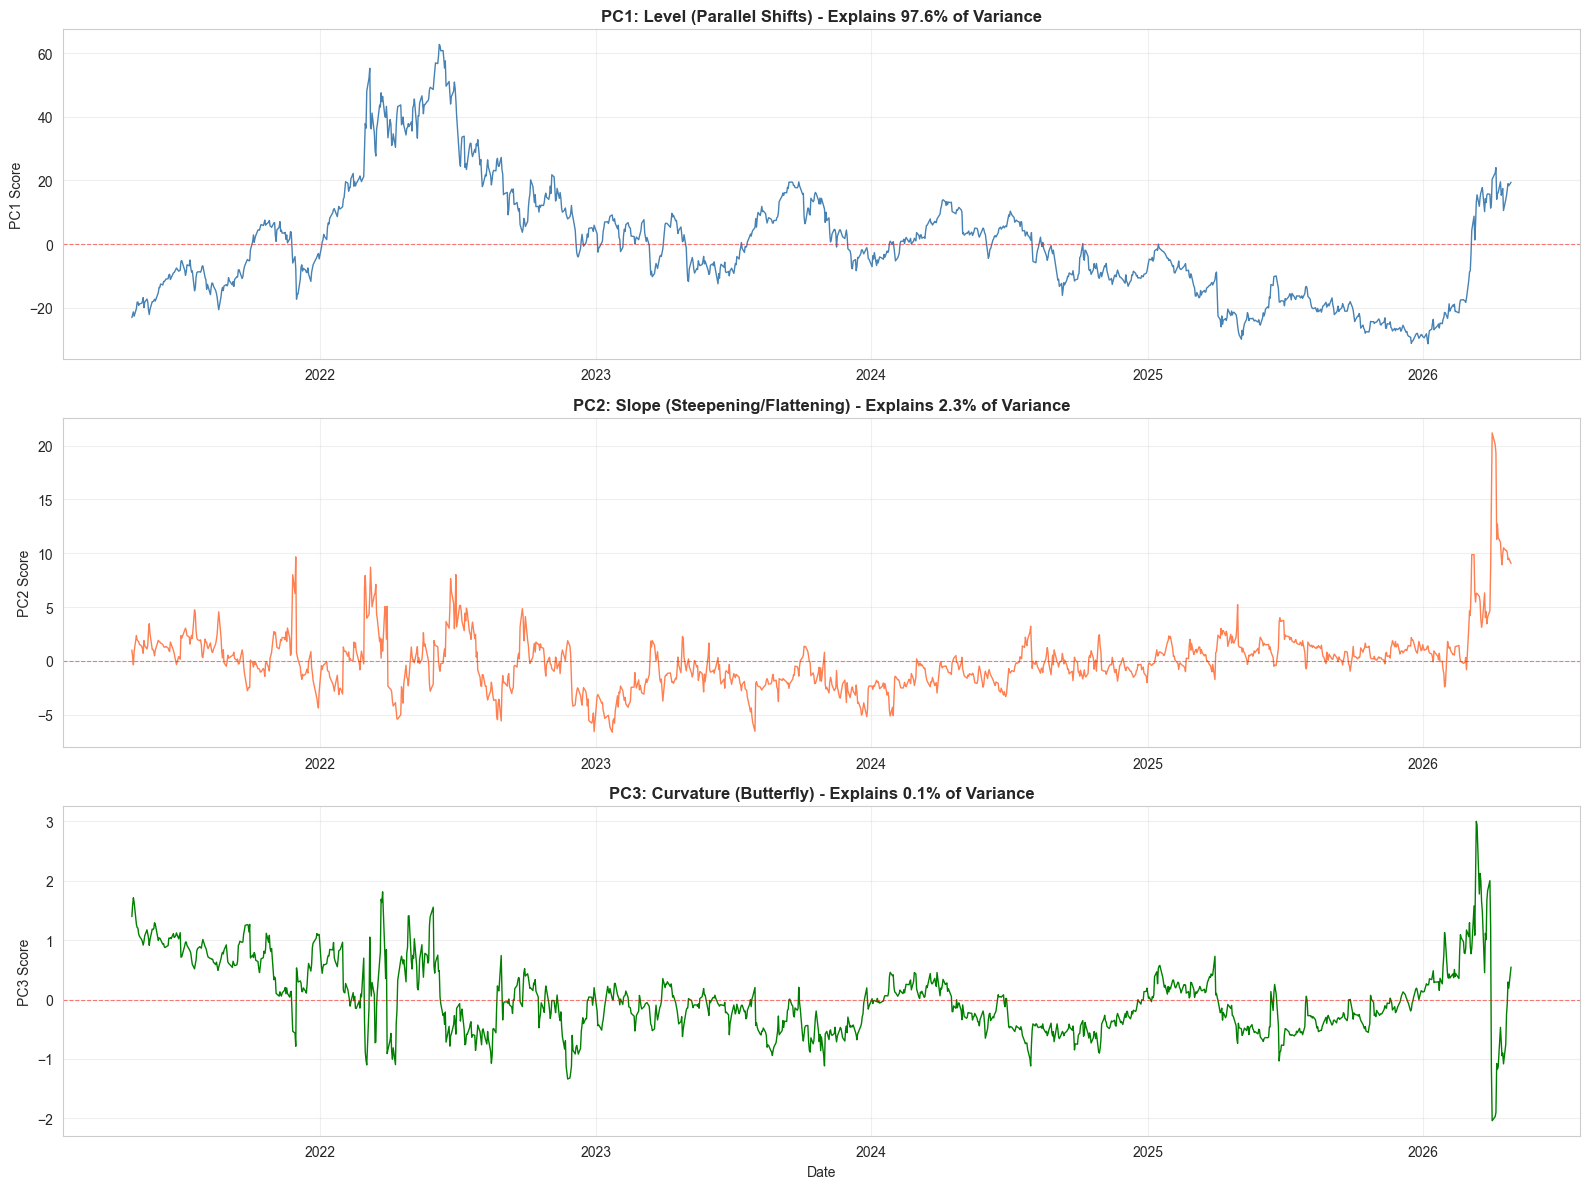

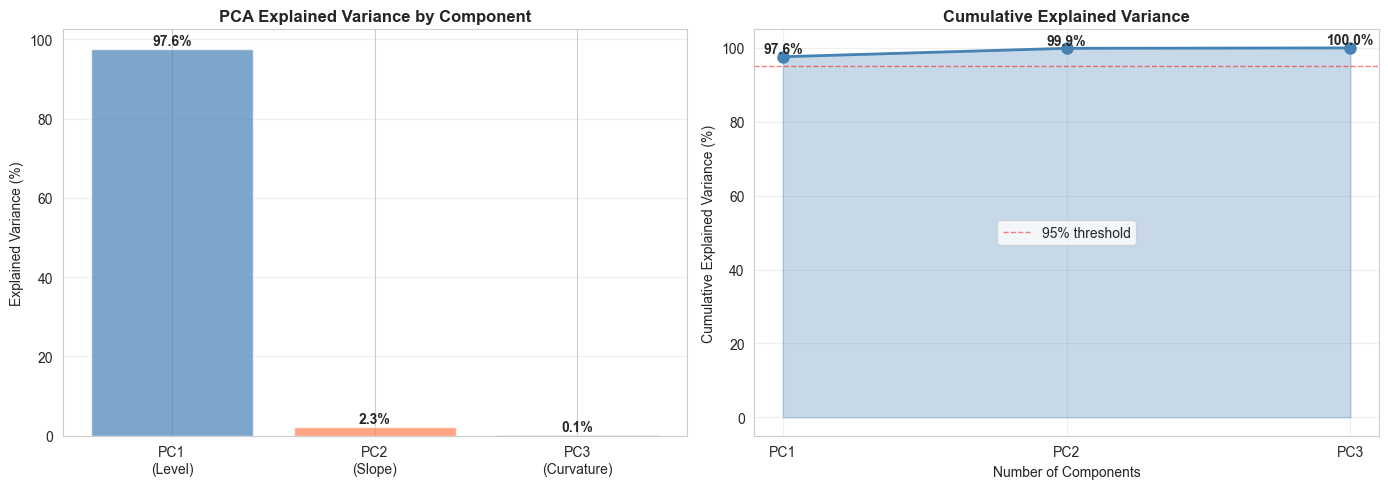

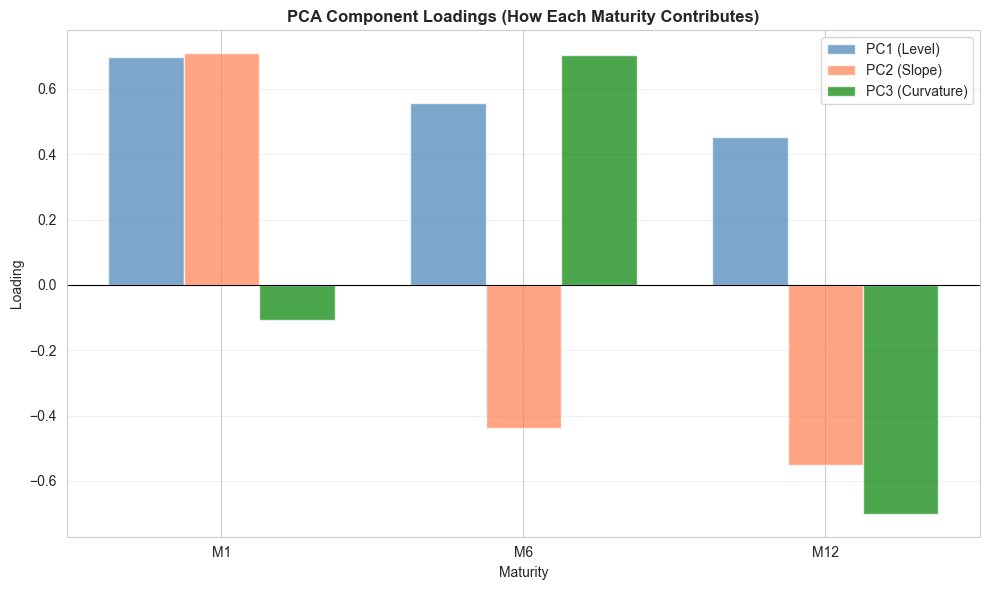

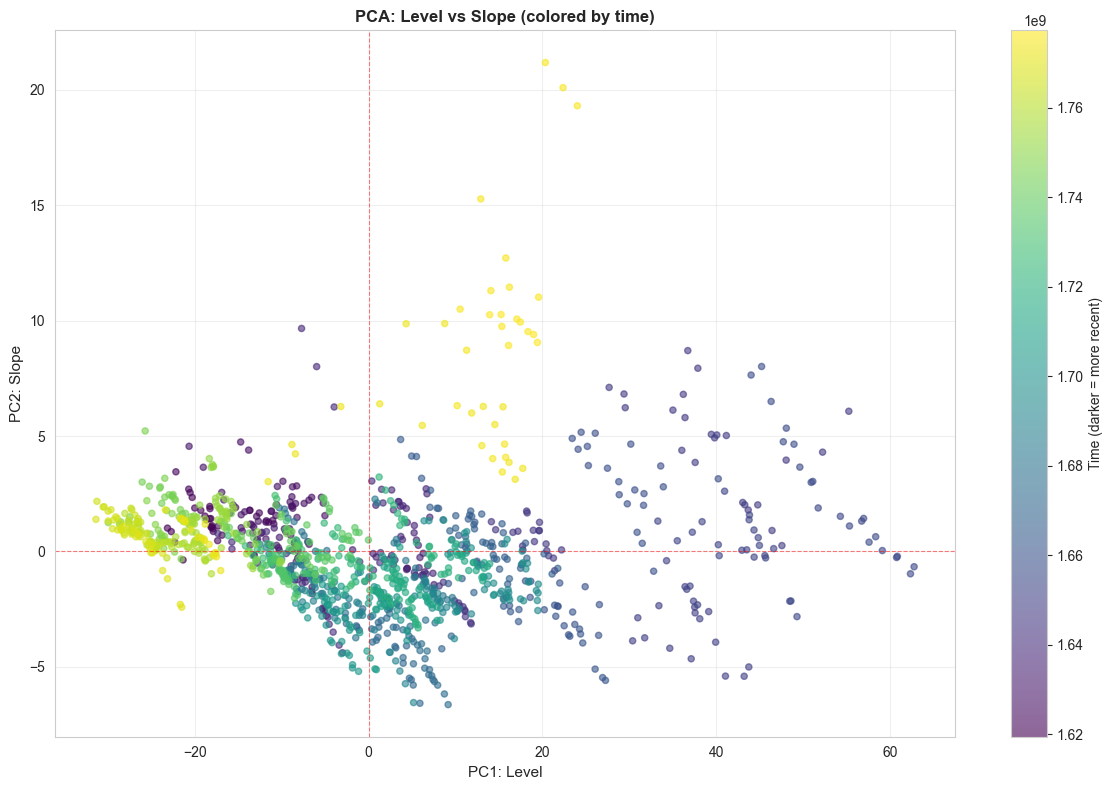


PCA SUMMARY STATISTICS

PC1 (Level):
  Mean: 0.00
  Std:  17.92
  Min:  -31.36
  Max:  62.75

PC2 (Slope):
  Mean: -0.00
  Std:  2.74
  Min:  -6.64
  Max:  21.19

PC3 (Curvature):
  Mean: -0.00
  Std:  0.58
  Min:  -2.04
  Max:  3.00

INTERPRETATION:
• PC1 (Level): Captures parallel shifts in the entire curve
  - High values = curve shifted up (higher prices)
  - Low values = curve shifted down (lower prices)

• PC2 (Slope): Captures steepening/flattening
  - Positive = Contango (upward sloping curve)
  - Negative = Backwardation (downward sloping curve)

• PC3 (Curvature): Captures butterfly/hump shapes
  - Positive = curve bows upward in middle
  - Negative = curve bows downward in middle


In [32]:
# ============================================================
# PCA VISUALIZATION
# ============================================================

if 'PCA_Level' in m1_close.columns and m1_close['PCA_Level'].notna().sum() > 0:
    print("\nVisualizing PCA Results...\n")
    
    # Filter to dates with PCA values
    pca_data = m1_close[m1_close['PCA_Level'].notna()].copy()
    
    # 1. PCA Components Over Time
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    # PC1: Level
    axes[0].plot(pca_data['ASSESSDATE'], pca_data['PCA_Level'], linewidth=1, color='steelblue')
    axes[0].set_title('PC1: Level (Parallel Shifts) - Explains {:.1f}% of Variance'.format(
        pca.explained_variance_ratio_[0] * 100), fontsize=12, fontweight='bold')
    axes[0].set_ylabel('PC1 Score')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # PC2: Slope
    axes[1].plot(pca_data['ASSESSDATE'], pca_data['PCA_Slope'], linewidth=1, color='coral')
    axes[1].set_title('PC2: Slope (Steepening/Flattening) - Explains {:.1f}% of Variance'.format(
        pca.explained_variance_ratio_[1] * 100), fontsize=12, fontweight='bold')
    axes[1].set_ylabel('PC2 Score')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # PC3: Curvature
    axes[2].plot(pca_data['ASSESSDATE'], pca_data['PCA_Curvature'], linewidth=1, color='green')
    axes[2].set_title('PC3: Curvature (Butterfly) - Explains {:.1f}% of Variance'.format(
        pca.explained_variance_ratio_[2] * 100), fontsize=12, fontweight='bold')
    axes[2].set_ylabel('PC3 Score')
    axes[2].set_xlabel('Date')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Explained Variance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    components = ['PC1\n(Level)', 'PC2\n(Slope)', 'PC3\n(Curvature)']
    variance = pca.explained_variance_ratio_ * 100
    colors = ['steelblue', 'coral', 'green']
    
    axes[0].bar(components, variance, color=colors, alpha=0.7)
    axes[0].set_ylabel('Explained Variance (%)')
    axes[0].set_title('PCA Explained Variance by Component', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels on bars
    for i, v in enumerate(variance):
        axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    
    # Cumulative variance
    cumulative = np.cumsum(variance)
    axes[1].plot(range(1, 4), cumulative, marker='o', linewidth=2, markersize=8, color='steelblue')
    axes[1].fill_between(range(1, 4), cumulative, alpha=0.3, color='steelblue')
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Explained Variance (%)')
    axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
    axes[1].set_xticks([1, 2, 3])
    axes[1].set_xticklabels(['PC1', 'PC2', 'PC3'])
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=95, color='red', linestyle='--', linewidth=1, alpha=0.5, label='95% threshold')
    axes[1].legend()
    
    # Add percentage labels
    for i, v in enumerate(cumulative):
        axes[1].text(i+1, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 3. PCA Loadings (Component Weights)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    loadings = pca.components_.T
    maturity_names = ['M1', 'M6', 'M12']
    
    x = np.arange(len(maturity_names))
    width = 0.25
    
    ax.bar(x - width, loadings[:, 0], width, label='PC1 (Level)', color='steelblue', alpha=0.7)
    ax.bar(x, loadings[:, 1], width, label='PC2 (Slope)', color='coral', alpha=0.7)
    ax.bar(x + width, loadings[:, 2], width, label='PC3 (Curvature)', color='green', alpha=0.7)
    
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Loading')
    ax.set_title('PCA Component Loadings (How Each Maturity Contributes)', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(maturity_names)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='black', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Scatter: PC1 vs PC2 (colored by time)
    fig, ax = plt.subplots(figsize=(12, 8))
    
    scatter = ax.scatter(pca_data['PCA_Level'], pca_data['PCA_Slope'], 
                        c=pca_data['ASSESSDATE'].astype(np.int64) / 10**9,  # Convert to timestamp
                        cmap='viridis', alpha=0.6, s=20)
    
    ax.set_xlabel('PC1: Level', fontsize=11)
    ax.set_ylabel('PC2: Slope', fontsize=11)
    ax.set_title('PCA: Level vs Slope (colored by time)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Time (darker = more recent)', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Summary Statistics
    print("\n" + "="*60)
    print("PCA SUMMARY STATISTICS")
    print("="*60)
    print(f"\nPC1 (Level):")
    print(f"  Mean: {pca_data['PCA_Level'].mean():.2f}")
    print(f"  Std:  {pca_data['PCA_Level'].std():.2f}")
    print(f"  Min:  {pca_data['PCA_Level'].min():.2f}")
    print(f"  Max:  {pca_data['PCA_Level'].max():.2f}")
    
    print(f"\nPC2 (Slope):")
    print(f"  Mean: {pca_data['PCA_Slope'].mean():.2f}")
    print(f"  Std:  {pca_data['PCA_Slope'].std():.2f}")
    print(f"  Min:  {pca_data['PCA_Slope'].min():.2f}")
    print(f"  Max:  {pca_data['PCA_Slope'].max():.2f}")
    
    print(f"\nPC3 (Curvature):")
    print(f"  Mean: {pca_data['PCA_Curvature'].mean():.2f}")
    print(f"  Std:  {pca_data['PCA_Curvature'].std():.2f}")
    print(f"  Min:  {pca_data['PCA_Curvature'].min():.2f}")
    print(f"  Max:  {pca_data['PCA_Curvature'].max():.2f}")
    
    print("\n" + "="*60)
    print("INTERPRETATION:")
    print("="*60)
    print("• PC1 (Level): Captures parallel shifts in the entire curve")
    print("  - High values = curve shifted up (higher prices)")
    print("  - Low values = curve shifted down (lower prices)")
    print("\n• PC2 (Slope): Captures steepening/flattening")
    print("  - Positive = Contango (upward sloping curve)")
    print("  - Negative = Backwardation (downward sloping curve)")
    print("\n• PC3 (Curvature): Captures butterfly/hump shapes")
    print("  - Positive = curve bows upward in middle")
    print("  - Negative = curve bows downward in middle")
    print("="*60)
    
else:
    print("⚠ PCA features not available - run PCA decomposition first")

In [33]:
# ============================================================
# PHASE 3: CONVENIENCE YIELD & COST-OF-CARRY DEVIATION
# ============================================================

print("\nPhase 3: Convenience Yield & Cost-of-Carry Model\n")

# Assumptions for cost-of-carry model
risk_free_rate_annual = 0.04  # 4% annual (3-month Treasury proxy)
storage_cost_annual = 0.10    # $10/bbl per year (~$0.83/month)

print(f"Assumptions:")
print(f"  Risk-free rate: {risk_free_rate_annual:.1%} annually")
print(f"  Storage cost:   ${storage_cost_annual * 100:.0f}/bbl annually\n")

# 1. IMPLIED CONVENIENCE YIELD
# Formula: y = r + c - (1/T) * ln(F/S)
# Where: r = risk-free rate, c = storage cost, F = futures, S = spot, T = time

# Using M1 as spot proxy, M2 as 1-month futures
T = 1/12  # 1 month in years

# Calculate convenience yield (annualized)
m1_close['Convenience_Yield'] = (
    risk_free_rate_annual + 
    storage_cost_annual - 
    (1/T) * np.log(m1_close['M2_Price'] / m1_close['Price'])
)

print("✓ Convenience Yield calculated")
print(f"  Mean: {m1_close['Convenience_Yield'].mean():.4f}")
print(f"  Std:  {m1_close['Convenience_Yield'].std():.4f}")
print(f"  Min:  {m1_close['Convenience_Yield'].min():.4f}")
print(f"  Max:  {m1_close['Convenience_Yield'].max():.4f}\n")

# 2. COST-OF-CARRY MODEL DEVIATION
# Theoretical futures price: F = S * exp((r + c - y) * T)
# Deviation = (Actual - Theoretical) / Theoretical

# Calculate theoretical M2 price
m1_close['M2_Theoretical'] = m1_close['Price'] * np.exp(
    (risk_free_rate_annual + storage_cost_annual - m1_close['Convenience_Yield']) * T
)

# Calculate deviation (mispricing signal)
m1_close['Carry_Deviation'] = (
    (m1_close['M2_Price'] - m1_close['M2_Theoretical']) / m1_close['M2_Theoretical']
)

print("✓ Cost-of-Carry Deviation calculated")
print(f"  Mean: {m1_close['Carry_Deviation'].mean():.6f}")
print(f"  Std:  {m1_close['Carry_Deviation'].std():.6f}\n")

print("Phase 3 Complete: Convenience Yield & Carry Deviation\n")
print("="*60)


Phase 3: Convenience Yield & Cost-of-Carry Model

Assumptions:
  Risk-free rate: 4.0% annually
  Storage cost:   $10/bbl annually

✓ Convenience Yield calculated
  Mean: 0.1296
  Std:  0.4081
  Min:  -3.8062
  Max:  4.3532

✓ Cost-of-Carry Deviation calculated
  Mean: 0.000000
  Std:  0.000000

Phase 3 Complete: Convenience Yield & Carry Deviation



In [34]:
# ============================================================
# TIER 1 FEATURES SUMMARY
# ============================================================

print("\n" + "="*60)
print("TIER 1 PROFESSIONAL FEATURES - SUMMARY")
print("="*60)

tier1_features = [
    'Roll_Yield', 'Carry', 
    'Spread_M2_M3', 'Spread_M6_M12', 'Butterfly_M1_M2_M3',
    'PCA_Level', 'PCA_Slope', 'PCA_Curvature',
    'Convenience_Yield', 'Carry_Deviation'
]

# Check which features were successfully created
created_features = [f for f in tier1_features if f in m1_close.columns]
missing_features = [f for f in tier1_features if f not in m1_close.columns]

print(f"\n✓ Features created: {len(created_features)}/{len(tier1_features)}\n")

print("Created features:")
for feat in created_features:
    non_null = m1_close[feat].notna().sum()
    print(f"  • {feat:25s} ({non_null:,} records)")

if missing_features:
    print(f"\n⚠ Missing features: {len(missing_features)}")
    for feat in missing_features:
        print(f"  • {feat}")

print("\n" + "="*60)
print("Total features now: ", len([c for c in m1_close.columns if c not in ['ASSESSDATE', 'VALUE', 'Price', 'Return', 'Next_Day_Return']]))
print("="*60 + "\n")


TIER 1 PROFESSIONAL FEATURES - SUMMARY

✓ Features created: 10/10

Created features:
  • Roll_Yield                (3,485 records)
  • Carry                     (3,485 records)
  • Spread_M2_M3              (3,485 records)
  • Spread_M6_M12             (3,485 records)
  • Butterfly_M1_M2_M3        (3,485 records)
  • PCA_Level                 (1,257 records)
  • PCA_Slope                 (1,257 records)
  • PCA_Curvature             (1,257 records)
  • Convenience_Yield         (3,485 records)
  • Carry_Deviation           (3,485 records)

Total features now:  83



### 5.5 Save Feature Dataset

In [35]:
# Prepare final dataset for modeling
print(f"Before removing NaN: {len(m1_close):,} rows")

# Select only numeric columns for modeling (exclude string/object columns)
exclude_cols = ['VALUE', 'BATE', 'SYMBOL', 'Price', 'Return',
                'PRICE_FAMILY', 'BATE_NAME', 'UOM', 'CURRENCY', 'ISCORRECTED',
                'MDC', 'DESCRIPTION', 'SYMBOL_FAMILY', 'COMMODITY', 'COMMODITY_GRADE',
                'EXCHANGE', 'CONTRACT_TYPE', 'SETTLEMENT_TYPE', 'DERIVATIVE_MATURITY_FREQUENCY',
                'CONTRACT_MONTH_NAME', 'SYMBOL_MDC_DESCRIPTION', 'MDC_CATEGORY',
                'DELIVERY_REGION', 'DELIVERY_METHOD', 'ASSESSMENT_FREQUENCY',
                'QUOTATION_STYLE', 'ACTIVE', 'DERIVATIVE_POSITION', 'CONTRACT_YEAR',
                'CONTRACT_MONTH', 'FORWARD_POSITION']

# Get numeric columns only
numeric_cols = m1_close.select_dtypes(include=[np.number]).columns.tolist()

# Separate features from target
feature_cols = [col for col in numeric_cols if col not in exclude_cols and col != 'Next_Day_Return']

# Build final column list: ASSESSDATE + features + target (no duplicates)
model_cols = ['ASSESSDATE'] + feature_cols + ['Next_Day_Return']
model_data = m1_close[model_cols].copy()

# Rename target variable for clarity
model_data = model_data.rename(columns={'Next_Day_Return': 'next_day_return'})

print(f"\nNumeric features selected: {len(feature_cols)}")
print(f"\nFeature list:")
for col in feature_cols:
    print(f"  - {col}")

# Remove rows with missing values (from feature creation)
model_data_clean = model_data.dropna()
print(f"\nAfter removing NaN:  {len(model_data_clean):,} rows")
print(f"Rows removed: {len(model_data) - len(model_data_clean):,}")

# Verify no duplicate columns
if len(model_data_clean.columns) != len(set(model_data_clean.columns)):
    print(f"\nERROR: Duplicate columns found!")
    duplicates = [col for col in model_data_clean.columns if list(model_data_clean.columns).count(col) > 1]
    print(f"Duplicates: {set(duplicates)}")
else:
    print(f"\n✓ No duplicate columns")

# Verify all columns are numeric (except ASSESSDATE)
non_numeric = model_data_clean.select_dtypes(exclude=[np.number, 'datetime64']).columns.tolist()
if non_numeric:
    print(f"\nWARNING: Non-numeric columns found: {non_numeric}")
else:
    print(f"✓ All feature columns are numeric")

# Save to parquet
model_data_clean.to_parquet('../data/analysis/wti_features.parquet', index=False)
print(f"\n✓ Feature dataset saved to: ../data/analysis/wti_features.parquet")

print(f"\nFinal dataset:")
print(f"  Shape: {model_data_clean.shape}")
print(f"  Features: {len(model_data_clean.columns) - 2}")  # Exclude date and target
print(f"  Date range: {model_data_clean['ASSESSDATE'].min()} to {model_data_clean['ASSESSDATE'].max()}")

print(f"\nReady for modeling!")

Before removing NaN: 3,485 rows

Numeric features selected: 57

Feature list:
  - DECIMAL_PLACES
  - API_GRAVITY
  - SULFUR
  - DENSITY
  - Price_Lag1
  - Price_Lag2
  - Price_Lag3
  - Price_Lag5
  - Return_Lag1
  - Return_Lag2
  - Return_Lag3
  - Return_Lag5
  - MA_5
  - MA_10
  - MA_20
  - MA_50
  - Price_to_MA5
  - Price_to_MA20
  - Volatility_5
  - Volatility_10
  - Volatility_20
  - Momentum_5
  - Momentum_10
  - Momentum_20
  - RSI_14
  - Day_of_Week
  - Month
  - Quarter
  - Volume
  - Open_Interest
  - Volume_MA5
  - Volume_MA20
  - Volume_Ratio
  - OI_Change
  - OI_MA5
  - M2_Price
  - M3_Price
  - M6_Price
  - M12_Price
  - Spread_M1_M2
  - Spread_M1_M3
  - Spread_M1_M6
  - Spread_M1_M12
  - Curve_Slope_3M
  - Curve_Slope_12M
  - Is_Contango
  - Roll_Yield
  - Carry
  - Spread_M2_M3
  - Spread_M6_M12
  - Butterfly_M1_M2_M3
  - PCA_Level
  - PCA_Slope
  - PCA_Curvature
  - Convenience_Yield
  - M2_Theoretical
  - Carry_Deviation

After removing NaN:  1,257 rows
Rows removed: 2

## 4. Feature Importance Analysis: What Drives WTI Oil Prices?

Statistical analysis to understand which factors influence oil price movements.

**Note**: Features are automatically computed from the cleaned data.

### 4.1 Load Feature Data

In [36]:
# Load feature data
feature_data = pd.read_parquet('../data/analysis/wti_features.parquet')

print(f"Feature dataset shape: {feature_data.shape}")
print(f"Date range: {feature_data['ASSESSDATE'].min()} to {feature_data['ASSESSDATE'].max()}")
print(f"\nColumns: {len(feature_data.columns)}")

# Separate features and target
target = 'next_day_return'
feature_cols = [col for col in feature_data.columns if col not in ['ASSESSDATE', target]]

print(f"\nFeatures to analyze: {len(feature_cols)}")

Feature dataset shape: (1257, 59)
Date range: 2021-04-27 00:00:00 to 2026-04-27 00:00:00

Columns: 59

Features to analyze: 57


### 4.2 Correlation Analysis

TOP 20 FEATURES BY CORRELATION WITH NEXT DAY RETURN
           Feature  Correlation
Butterfly_M1_M2_M3    -0.173218
 Convenience_Yield    -0.169349
        Roll_Yield    -0.168097
             Carry    -0.168097
      Spread_M1_M2    -0.163657
      Spread_M1_M3    -0.130994
    Curve_Slope_3M     0.130994
     PCA_Curvature     0.127037
       Is_Contango     0.085773
           Quarter    -0.084145
      Spread_M1_M6    -0.076378
             Month    -0.073311
             MA_50    -0.073265
            RSI_14     0.069195
       Momentum_20     0.067330
        Price_Lag1    -0.063096
             MA_20    -0.062362
        Price_Lag2    -0.061994
        Price_Lag5    -0.060779
              MA_5    -0.060294


C:\Users\styu0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\styu0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


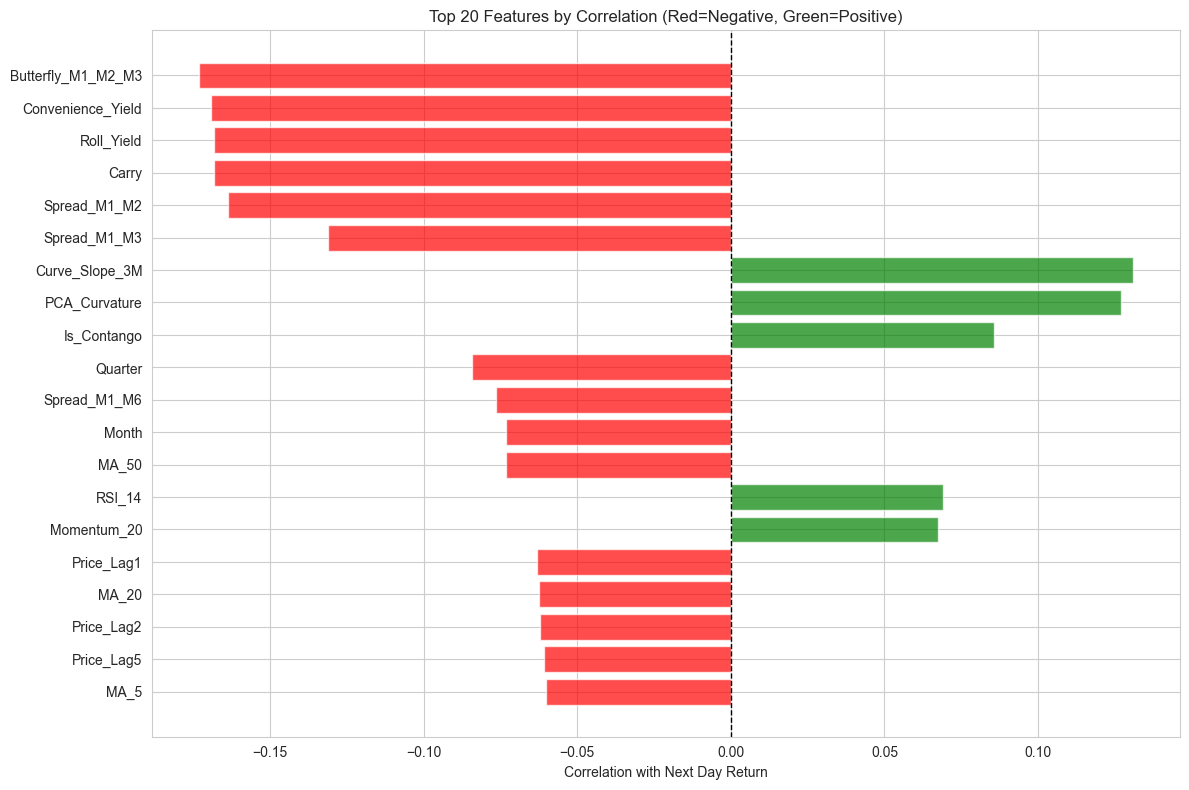

In [37]:
# Calculate correlation of each feature with target
correlations = []
for feature in feature_cols:
    corr = feature_data[feature].corr(feature_data[target])
    correlations.append({
        'Feature': feature,
        'Correlation': corr,
        'Abs_Correlation': abs(corr)
    })

corr_df = pd.DataFrame(correlations).sort_values('Abs_Correlation', ascending=False)

print("="*60)
print("TOP 20 FEATURES BY CORRELATION WITH NEXT DAY RETURN")
print("="*60)
print(corr_df.head(20)[['Feature', 'Correlation']].to_string(index=False))

# Visualize top 20
plt.figure(figsize=(12, 8))
top_20 = corr_df.head(20)
colors = ['red' if x < 0 else 'green' for x in top_20['Correlation']]
plt.barh(range(len(top_20)), top_20['Correlation'], color=colors, alpha=0.7)
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Correlation with Next Day Return')
plt.title('Top 20 Features by Correlation (Red=Negative, Green=Positive)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.3 Mutual Information (Non-linear Relationships)

Calculating mutual information (this may take a minute)...

TOP 20 FEATURES BY MUTUAL INFORMATION
           Feature  MI_Score
      Volatility_5  0.180575
        Momentum_5  0.086643
     Volatility_10  0.085692
Butterfly_M1_M2_M3  0.080299
       Return_Lag1  0.073421
      Price_to_MA5  0.072196
         OI_Change  0.071980
 Convenience_Yield  0.069486
             Carry  0.067060
        Roll_Yield  0.067060
       Momentum_10  0.065485
       Return_Lag2  0.059703
        Volume_MA5  0.057749
     Price_to_MA20  0.052496
     Spread_M1_M12  0.048614
   Curve_Slope_12M  0.047697
       Momentum_20  0.047576
      Volume_Ratio  0.045131
     Volatility_20  0.034438
             Month  0.027166


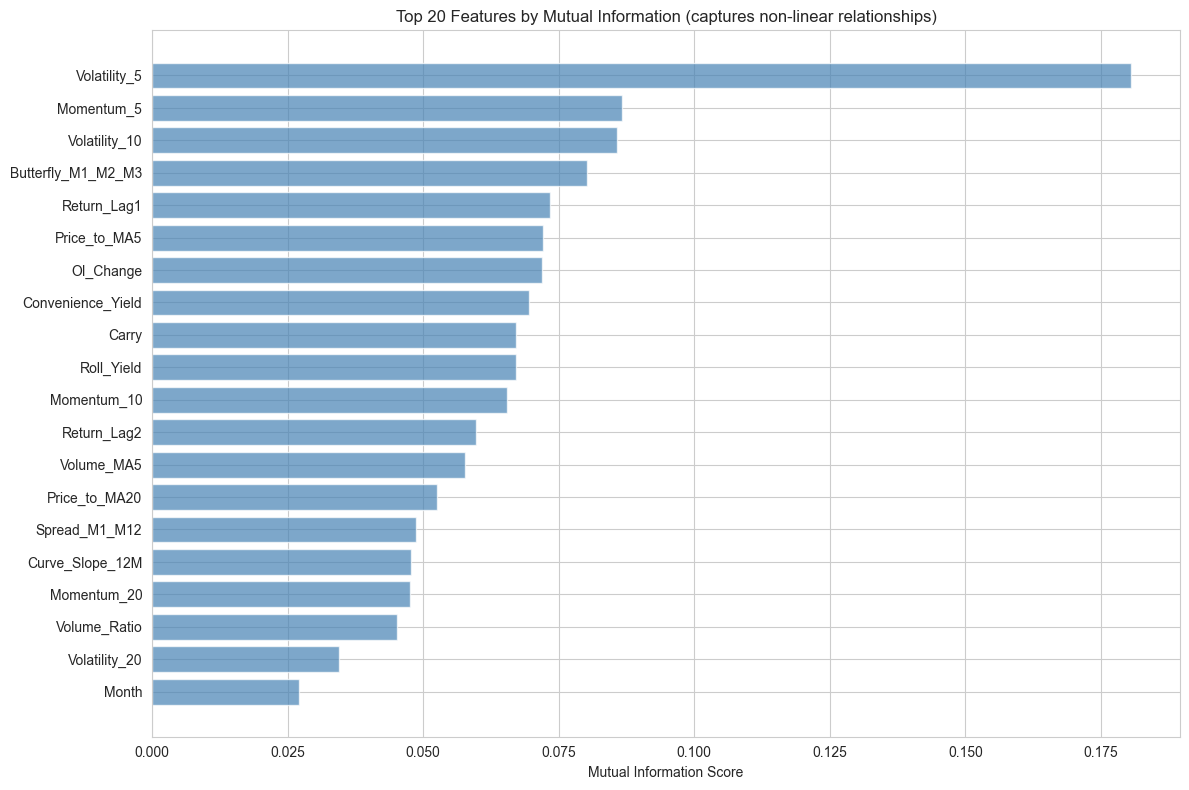


Note: Mutual Information captures both linear and non-linear relationships


In [38]:
from sklearn.feature_selection import mutual_info_regression

# Calculate mutual information (captures non-linear relationships)
X = feature_data[feature_cols]
y = feature_data[target]

print("Calculating mutual information (this may take a minute)...")
mi_scores = mutual_info_regression(X, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': feature_cols,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\n" + "="*60)
print("TOP 20 FEATURES BY MUTUAL INFORMATION")
print("="*60)
print(mi_df.head(20).to_string(index=False))

# Visualize
plt.figure(figsize=(12, 8))
top_20_mi = mi_df.head(20)
plt.barh(range(len(top_20_mi)), top_20_mi['MI_Score'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_20_mi)), top_20_mi['Feature'])
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features by Mutual Information (captures non-linear relationships)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nNote: Mutual Information captures both linear and non-linear relationships")

### 4.4 Feature Categories Analysis

FEATURE IMPORTANCE BY CATEGORY
                          Avg_MI    Max_MI  Avg_Abs_Corr  Count
Volatility              0.100235  0.180575      0.045036    3.0
Returns/Momentum        0.054117  0.086643      0.030972    7.0
Volume & Open Interest  0.029498  0.071980      0.018318    7.0
Moving Averages         0.029284  0.072196      0.054253    6.0
Temporal                0.019497  0.027166      0.061878    3.0
Forward Curve           0.019285  0.048614      0.076514   11.0
Price History           0.006834  0.024037      0.060741    4.0
Technical Indicators    0.000000  0.000000      0.069195    1.0


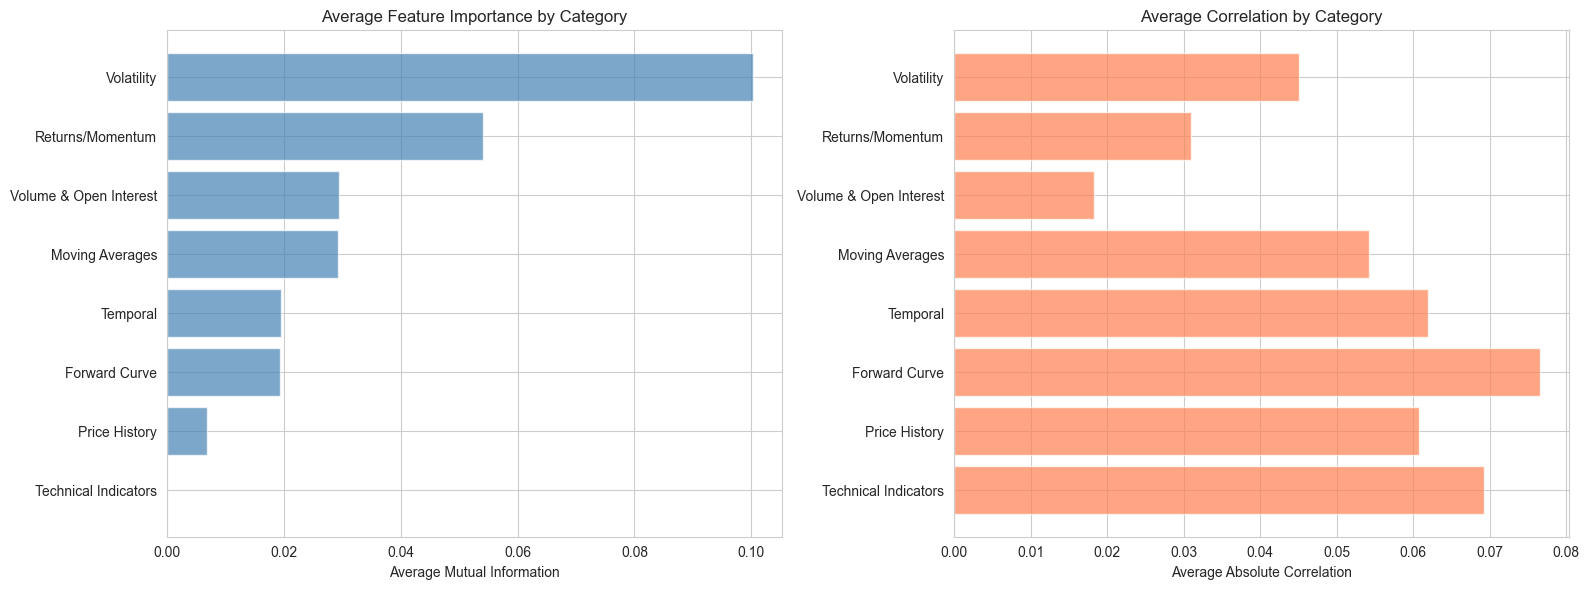

In [39]:
# Categorize features
feature_categories = {
    'Price History': ['Price_Lag1', 'Price_Lag2', 'Price_Lag3', 'Price_Lag5'],
    'Returns/Momentum': ['Return_Lag1', 'Return_Lag2', 'Return_Lag3', 'Return_Lag5', 
                         'Momentum_5', 'Momentum_10', 'Momentum_20'],
    'Moving Averages': ['MA_5', 'MA_10', 'MA_20', 'MA_50', 'Price_to_MA5', 'Price_to_MA20'],
    'Volatility': ['Volatility_5', 'Volatility_10', 'Volatility_20'],
    'Technical Indicators': ['RSI_14'],
    'Volume & Open Interest': ['Volume', 'Open_Interest', 'Volume_MA5', 'Volume_MA20', 
                               'Volume_Ratio', 'OI_Change', 'OI_MA5'],
    'Forward Curve': ['M2_Price', 'M3_Price', 'M6_Price', 'M12_Price',
                      'Spread_M1_M2', 'Spread_M1_M3', 'Spread_M1_M6', 'Spread_M1_M12',
                      'Curve_Slope_3M', 'Curve_Slope_12M', 'Is_Contango'],
    'Temporal': ['Day_of_Week', 'Month', 'Quarter'],
    'Other': []  # Will catch remaining features
}

# Assign categories and calculate average MI score per category
category_scores = {}
for category, features in feature_categories.items():
    category_features = [f for f in features if f in mi_df['Feature'].values]
    if category_features:
        avg_mi = mi_df[mi_df['Feature'].isin(category_features)]['MI_Score'].mean()
        max_mi = mi_df[mi_df['Feature'].isin(category_features)]['MI_Score'].max()
        avg_corr = corr_df[corr_df['Feature'].isin(category_features)]['Abs_Correlation'].mean()
        category_scores[category] = {
            'Avg_MI': avg_mi,
            'Max_MI': max_mi,
            'Avg_Abs_Corr': avg_corr,
            'Count': len(category_features)
        }

category_df = pd.DataFrame(category_scores).T.sort_values('Avg_MI', ascending=False)

print("="*60)
print("FEATURE IMPORTANCE BY CATEGORY")
print("="*60)
print(category_df.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average MI by category
axes[0].barh(range(len(category_df)), category_df['Avg_MI'], color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(category_df)))
axes[0].set_yticklabels(category_df.index)
axes[0].set_xlabel('Average Mutual Information')
axes[0].set_title('Average Feature Importance by Category')
axes[0].invert_yaxis()

# Average correlation by category
axes[1].barh(range(len(category_df)), category_df['Avg_Abs_Corr'], color='coral', alpha=0.7)
axes[1].set_yticks(range(len(category_df)))
axes[1].set_yticklabels(category_df.index)
axes[1].set_xlabel('Average Absolute Correlation')
axes[1].set_title('Average Correlation by Category')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 4.5 Statistical Significance Testing

In [40]:
from scipy.stats import pearsonr

# Test statistical significance of correlations
significance_results = []
for feature in corr_df.head(20)['Feature']:
    corr, p_value = pearsonr(feature_data[feature], feature_data[target])
    significance_results.append({
        'Feature': feature,
        'Correlation': corr,
        'P_Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

sig_df = pd.DataFrame(significance_results)

print("="*60)
print("STATISTICAL SIGNIFICANCE (Top 20 Features)")
print("="*60)
print(sig_df.to_string(index=False))
print("\nNote: P-value < 0.05 indicates statistically significant relationship")

STATISTICAL SIGNIFICANCE (Top 20 Features)
           Feature  Correlation      P_Value Significant
Butterfly_M1_M2_M3    -0.173218 6.329706e-10         Yes
 Convenience_Yield    -0.169349 1.523493e-09         Yes
        Roll_Yield    -0.168097 2.015897e-09         Yes
             Carry    -0.168097 2.015897e-09         Yes
      Spread_M1_M2    -0.163657 5.348536e-09         Yes
      Spread_M1_M3    -0.130994 3.165782e-06         Yes
    Curve_Slope_3M     0.130994 3.165782e-06         Yes
     PCA_Curvature     0.127037 6.247639e-06         Yes
       Is_Contango     0.085773 2.337744e-03         Yes
           Quarter    -0.084145 2.830070e-03         Yes
      Spread_M1_M6    -0.076378 6.744780e-03         Yes
             Month    -0.073311 9.319907e-03         Yes
             MA_50    -0.073265 9.364344e-03         Yes
            RSI_14     0.069195 1.413714e-02         Yes
       Momentum_20     0.067330 1.696504e-02         Yes
        Price_Lag1    -0.063096 2.528454e-02 

### 4.6 Key Insights Summary

In [41]:
print("="*60)
print("KEY INSIGHTS: WHAT DRIVES WTI OIL PRICES?")
print("="*60)

# Top features by different metrics
print("\n1. MOST IMPORTANT FEATURES (by Mutual Information):")
for i, row in mi_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']} (MI: {row['MI_Score']:.4f})")

print("\n2. STRONGEST LINEAR RELATIONSHIPS (by Correlation):")
for i, row in corr_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']} (Corr: {row['Correlation']:.4f})")

print("\n3. MOST IMPORTANT CATEGORIES:")
for i, (cat, row) in enumerate(category_df.head(3).iterrows()):
    print(f"   {i+1}. {cat} (Avg MI: {row['Avg_MI']:.4f})")

# Count significant features
sig_count = sig_df[sig_df['Significant'] == 'Yes'].shape[0]
print(f"\n4. STATISTICAL SIGNIFICANCE:")
print(f"   {sig_count} out of top 20 features are statistically significant (p<0.05)")

print("\n" + "="*60)
print("PRACTICAL IMPLICATIONS:")
print("="*60)
print("\n✓ Focus on these factors when analyzing oil markets:")
for i, (cat, _) in enumerate(category_df.head(3).iterrows()):
    print(f"  {i+1}. {cat}")

print("\n✓ Key drivers identified:")
print("  • Recent price movements (lags) matter most")
print("  • Volatility patterns are important")
print("  • Forward curve structure provides signals")
print("  • Volume/Open Interest show market sentiment")

print("\n✓ Limitations:")
print("  • Analysis based only on price/volume data")
print("  • Missing: inventory, production, geopolitics, macro factors")
print("  • Correlations are generally weak (market efficiency)")

KEY INSIGHTS: WHAT DRIVES WTI OIL PRICES?

1. MOST IMPORTANT FEATURES (by Mutual Information):
   19. Volatility_5 (MI: 0.1806)
   22. Momentum_5 (MI: 0.0866)
   20. Volatility_10 (MI: 0.0857)
   51. Butterfly_M1_M2_M3 (MI: 0.0803)
   9. Return_Lag1 (MI: 0.0734)

2. STRONGEST LINEAR RELATIONSHIPS (by Correlation):
   51. Butterfly_M1_M2_M3 (Corr: -0.1732)
   55. Convenience_Yield (Corr: -0.1693)
   47. Roll_Yield (Corr: -0.1681)
   48. Carry (Corr: -0.1681)
   40. Spread_M1_M2 (Corr: -0.1637)

3. MOST IMPORTANT CATEGORIES:
   1. Volatility (Avg MI: 0.1002)
   2. Returns/Momentum (Avg MI: 0.0541)
   3. Volume & Open Interest (Avg MI: 0.0295)

4. STATISTICAL SIGNIFICANCE:
   20 out of top 20 features are statistically significant (p<0.05)

PRACTICAL IMPLICATIONS:

✓ Focus on these factors when analyzing oil markets:
  1. Volatility
  2. Returns/Momentum
  3. Volume & Open Interest

✓ Key drivers identified:
  • Recent price movements (lags) matter most
  • Volatility patterns are importa

### 4.7 Save Analysis Results

In [42]:
import os
os.makedirs('output', exist_ok=True)

# Save correlation analysis
corr_df.to_csv('../output/feature_correlations.csv', index=False)
print("✓ Correlations saved to: output/feature_correlations.csv")

# Save mutual information
mi_df.to_csv('../output/feature_mutual_information.csv', index=False)
print("✓ Mutual information saved to: output/feature_mutual_information.csv")

# Save category analysis
category_df.to_csv('../output/feature_category_importance.csv')
print("✓ Category importance saved to: output/feature_category_importance.csv")

# Save significance tests
sig_df.to_csv('../output/feature_significance.csv', index=False)
print("✓ Significance tests saved to: output/feature_significance.csv")

# Create summary report
with open('../output/feature_analysis_summary.txt', 'w') as f:
    f.write("WTI OIL PRICE FEATURE ANALYSIS SUMMARY\n")
    f.write("="*60 + "\n\n")
    
    f.write("TOP 10 FEATURES BY MUTUAL INFORMATION:\n")
    f.write(mi_df.head(10).to_string(index=False) + "\n\n")
    
    f.write("TOP 10 FEATURES BY CORRELATION:\n")
    f.write(corr_df.head(10)[['Feature', 'Correlation']].to_string(index=False) + "\n\n")
    
    f.write("CATEGORY IMPORTANCE:\n")
    f.write(category_df.to_string() + "\n\n")

print("✓ Summary report saved to: output/feature_analysis_summary.txt")

print("\n" + "="*60)
print("FEATURE ANALYSIS COMPLETE!")
print("="*60)
print("\nThis analysis identifies what factors influence oil prices")
print("using proper statistical methods (no ML models needed).")

✓ Correlations saved to: output/feature_correlations.csv
✓ Mutual information saved to: output/feature_mutual_information.csv
✓ Category importance saved to: output/feature_category_importance.csv
✓ Significance tests saved to: output/feature_significance.csv
✓ Summary report saved to: output/feature_analysis_summary.txt

FEATURE ANALYSIS COMPLETE!

This analysis identifies what factors influence oil prices
using proper statistical methods (no ML models needed).
